# Phase 2 Step 3 — Phase 1.5 Ensemble 74 종목 확장 (`03_phase15_ensemble_top50.ipynb`)

> **목적**: Phase 1.5 v8 Performance-Weighted Ensemble 을 universe 74 종목 전체에 학습.

## 구성

- **LSTM v4 best (3ch_vix)**: input_size=4 (rv_d, rv_w, rv_m, vix_log), hidden=32, dropout=0.3
- **HAR-RV**: 3 변수 OLS (Corsi 2009, log domain)
- **Performance-Weighted Ensemble**: 이전 fold OOS RMSE 역수 비율 (Diebold-Pauly 1987)

## Walk-Forward 파라미터 (Phase 1.5 v4 일관)

```
IS = 1,250 영업일 (~5년)
purge = 21 (forward target window)
embargo = 63
OOS = 21
step = 21
seq_len = 63
```

## 결정 4 — 신규 종목 reset

```
신규 편입 종목: 첫 fold 0.5/0.5 warmup
기존 종목: 이전 모든 fold history 유지 (compute_performance_weights 가 자동 처리)
```

## ⚠️ 실행 시간

| 모드 | 종목 수 | 시간 (CPU) | 시간 (GPU) |
|---|---|---|---|
| **PoC** | 5 종목 | ~30분 | ~5분 |
| **확장** | 30 종목 | ~3-5시간 | ~30분-1시간 |
| **전체** | 74 종목 | ~24-48시간 | ~5-10시간 |

→ 본 노트북은 **PoC 모드 (5 종목)** 를 default 로 함. 코드 검증 후 사용자가 본 학습 별도 실행.

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + GPU 확인 + autoreload |
| §2 | universe + daily_panel 로드 |
| §3 | 학습 모드 선택 (PoC / 확장 / 전체) |
| §4 | 종목별 walk-forward 학습 + HAR (시간 병목) |
| §5 | Performance-Weighted ensemble 가중치 계산 |
| §6 | 결과 검증 (RMSE 분포, fold 별 가중치) |
| §7 | 시각화 |


## §1. 환경 부트스트랩 + GPU 확인

In [1]:
# Jupyter 모듈 자동 리로드
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scripts.setup import bootstrap, BASE_DIR, DATA_DIR, OUTPUTS_DIR
from scripts.volatility_ensemble import (
    V4_BEST_CONFIG,
    run_walkforward_for_ticker,
    compute_performance_weights,
    run_ensemble_for_universe,
)

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '03_ensemble'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# GPU 확인
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\nDevice: {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

  Phase 2 BL Integration — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility

Device: cuda
  GPU: NVIDIA GeForce RTX 4090
  메모리: 25.8 GB


## §2. Universe + Daily Panel 로드

In [2]:
universe_csv = DATA_DIR / 'universe_top50_history.csv'
panel_csv = DATA_DIR / 'daily_panel.csv'

universe_df = pd.read_csv(universe_csv, parse_dates=['cutoff_date'])
panel = pd.read_csv(panel_csv, parse_dates=['date'])

print(f'universe: {universe_df.shape} (unique {universe_df["ticker"].nunique()} 종목)')
print(f'panel   : {panel.shape}')
print(f'\npanel 컬럼: {list(panel.columns)}')
print(f'panel 종목 수: {panel["ticker"].nunique()}')

universe: (300, 6) (unique 74 종목)
panel   : (241422, 17)

panel 컬럼: ['date', 'close', 'log_ret', 'vol_21d', 'vol_60d', 'vol_252d', 'beta_252d', 'mcap_value', 'log_mcap', 'target_logrv', 'ticker', 'gics_sector', 'spy_close', 'vix', 'tnx', 'spy_log_ret', 'rf_daily']
panel 종목 수: 74


## §3. 학습 모드 선택

⭐ **본 노트북은 default 로 PoC 모드** (5 종목, ~30분 CPU / ~5분 GPU).
전체 학습은 본 노트북 검증 후 사용자가 별도 실행 권고 (`MODE = 'full'` 변경).

In [3]:
# ⭐ 모드 변경 가능 (사용자 결정: 옵션 A = full 74 종목)
MODE = 'full'   # 'poc' (5 종목) / 'core' (30 종목) / 'full' (74 종목, 본 단계 default)

if MODE == 'poc':
    TICKERS_SUBSET = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'BRK-B']  # 5 안정 대형주 (코드 검증용)
    print(f'PoC 모드: {len(TICKERS_SUBSET)} 종목')
elif MODE == 'core':
    # super-stable 종목 (6 OOS 연도 모두 등장한 33 종목 중 상위 30)
    cnt = universe_df.groupby('ticker').size().sort_values(ascending=False)
    TICKERS_SUBSET = cnt[cnt == universe_df['oos_year'].nunique()].index.tolist()[:30]
    print(f'Core 모드: {len(TICKERS_SUBSET)} 종목 (super-stable)')
else:
    TICKERS_SUBSET = None
    print(f'Full 모드: 전체 universe (74 종목, 옵션 A) ⭐')

print(f'\n예상 시간 ({DEVICE}):')
n = len(TICKERS_SUBSET) if TICKERS_SUBSET else universe_df['ticker'].nunique()
sec_per_fold = 5 if DEVICE == 'cuda' else 30
n_folds_avg = 80
total_min = n * n_folds_avg * sec_per_fold / 60
print(f'  {n} 종목 × ~{n_folds_avg} fold × {sec_per_fold}s/fold ≈ {total_min:.0f} 분 ({total_min/60:.1f} 시간)')

Full 모드: 전체 universe (74 종목, 옵션 A) ⭐

예상 시간 (cuda):
  74 종목 × ~80 fold × 5s/fold ≈ 493 분 (8.2 시간)


## §4. 종목별 walk-forward 학습 (시간 병목 ⚠️)

LSTM v4 + HAR-RV 매 fold 학습. 진행 출력 확인.

In [4]:
print('=' * 70)
print(f'학습 시작: MODE={MODE}, device={DEVICE}')
print('=' * 70)

t0 = time.time()
ensemble_df = run_ensemble_for_universe(
    panel_csv=panel_csv,
    universe_csv=universe_csv,
    out_dir=DATA_DIR,
    config=V4_BEST_CONFIG,
    device=DEVICE,
    tickers_subset=TICKERS_SUBSET,
    verbose=True,
)
elapsed = time.time() - t0
print(f'\n총 소요: {elapsed/60:.1f} 분')

학습 시작: MODE=full, device=cuda
  [ensemble] 전체 모드: 74 종목 학습
    [1/74] AAPL: 92 fold (123s)
    [2/74] ABBV: 92 fold (111s)
    [3/74] ABT: 92 fold (114s)
    [4/74] ACN: 92 fold (111s)
    [5/74] ADBE: 92 fold (93s)
    [6/74] AMD: 92 fold (88s)
    [7/74] AMGN: 92 fold (93s)
    [8/74] AMZN: 92 fold (104s)
    [9/74] AVGO: 92 fold (96s)
    [10/74] AXP: 92 fold (133s)
    [11/74] BA: 92 fold (99s)
    [12/74] BAC: 92 fold (123s)
    [13/74] BMY: 92 fold (96s)
    [14/74] BRK-B: 92 fold (104s)
    [15/74] BX: 92 fold (94s)
    [16/74] C: 92 fold (111s)
    [17/74] CAT: 92 fold (123s)
    [18/74] CHTR: 92 fold (102s)
    [19/74] CMCSA: 92 fold (108s)
    [20/74] COP: 92 fold (117s)
    [21/74] COST: 92 fold (94s)
    [22/74] CRM: 92 fold (105s)
    [23/74] CSCO: 92 fold (114s)
    [24/74] CVX: 92 fold (113s)
    [25/74] DHR: 92 fold (122s)
    [26/74] DIS: 92 fold (103s)
    [27/74] GE: 92 fold (90s)
    [28/74] GOOGL: 92 fold (106s)
    [29/74] GS: 92 fold (107s)
    [30/74] HD: 92 fol

## §5. 결과 검증

In [5]:
# 5-1. shape 검증
print(f'ensemble_df shape: {ensemble_df.shape}')
print(f'학습 종목 수: {ensemble_df["ticker"].nunique()}')
print(f'fold 수 (종목별 평균): {ensemble_df.groupby("ticker")["fold"].nunique().mean():.0f}')

# 5-2. RMSE 검증 (종목별 LSTM v4, HAR, Ensemble)
print(f'\n=== 종목별 OOS RMSE 비교 ===')
metrics = []
for ticker, df_t in ensemble_df.groupby('ticker'):
    valid = df_t.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(valid) == 0:
        continue
    rmse_lstm = np.sqrt(((valid['y_pred_lstm'] - valid['y_true']) ** 2).mean())
    rmse_har = np.sqrt(((valid['y_pred_har'] - valid['y_true']) ** 2).mean())
    rmse_ens = np.sqrt(((valid['y_pred_ensemble'] - valid['y_true']) ** 2).mean())
    metrics.append({
        'ticker': ticker,
        'n_obs': len(valid),
        'rmse_lstm': rmse_lstm,
        'rmse_har': rmse_har,
        'rmse_ensemble': rmse_ens,
        'best': min(['lstm', 'har', 'ensemble'], key=lambda x: {'lstm': rmse_lstm, 'har': rmse_har, 'ensemble': rmse_ens}[x])
    })
metrics_df = pd.DataFrame(metrics)
print(metrics_df.round(4).to_string())

print(f'\n=== best 모델 분포 ===')
print(metrics_df['best'].value_counts())

ensemble_df shape: (142338, 9)
학습 종목 수: 74
fold 수 (종목별 평균): 92

=== 종목별 OOS RMSE 비교 ===
   ticker  n_obs  rmse_lstm  rmse_har  rmse_ensemble      best
0    AAPL   1916   0.385400  0.370700       0.358800  ensemble
1    ABBV   1915   0.451800  0.375200       0.381000       har
2     ABT   1916   0.376400  0.361400       0.341800  ensemble
3     ACN   1916   0.479200  0.408000       0.396800  ensemble
4    ADBE   1916   0.427300  0.413700       0.400500  ensemble
5     AMD   1916   0.351700  0.328100       0.330300       har
6    AMGN   1916   0.438900  0.343200       0.355700       har
7    AMZN   1916   0.394800  0.369500       0.357500  ensemble
8    AVGO   1916   0.442400  0.376700       0.384300       har
9     AXP   1916   0.397400  0.426200       0.380000  ensemble
10     BA   1916   0.527700  0.405700       0.389000  ensemble
11    BAC   1916   0.364700  0.381400       0.335800  ensemble
12    BMY   1916   0.420200  0.351100       0.358200       har
13  BRK-B   1916   0.459300  0

## §6. Performance-Weighted 가중치 진화

In [6]:
# 종목별 fold 별 w_v4 가중치 (시간 동적 적응 시각화)
weights_summary = ensemble_df.groupby(['ticker', 'fold']).agg(
    w_v4=('w_v4', 'first'),
    w_har=('w_har', 'first'),
    date=('date', 'first'),
).reset_index()

print(f'가중치 진화 (종목별 fold 별 w_v4):')
print(weights_summary.head(20).to_string())

가중치 진화 (종목별 fold 별 w_v4):
   ticker  fold     w_v4    w_har       date
0    AAPL     0 0.500000 0.500000 2018-04-19
1    AAPL     1 0.509125 0.490875 2018-05-18
2    AAPL     2 0.435648 0.564352 2018-06-19
3    AAPL     3 0.457646 0.542354 2018-07-19
4    AAPL     4 0.537733 0.462267 2018-08-17
5    AAPL     5 0.490009 0.509991 2018-09-18
6    AAPL     6 0.496964 0.503036 2018-10-17
7    AAPL     7 0.551257 0.448743 2018-11-15
8    AAPL     8 0.523556 0.476444 2018-12-18
9    AAPL     9 0.586680 0.413320 2019-01-18
10   AAPL    10 0.502884 0.497116 2019-02-20
11   AAPL    11 0.538449 0.461551 2019-03-21
12   AAPL    12 0.518008 0.481992 2019-04-22
13   AAPL    13 0.516744 0.483256 2019-05-21
14   AAPL    14 0.589394 0.410606 2019-06-20
15   AAPL    15 0.510153 0.489847 2019-07-22
16   AAPL    16 0.509151 0.490849 2019-08-20
17   AAPL    17 0.528760 0.471240 2019-09-19
18   AAPL    18 0.448150 0.551850 2019-10-18
19   AAPL    19 0.554096 0.445904 2019-11-18


## §7. 시각화

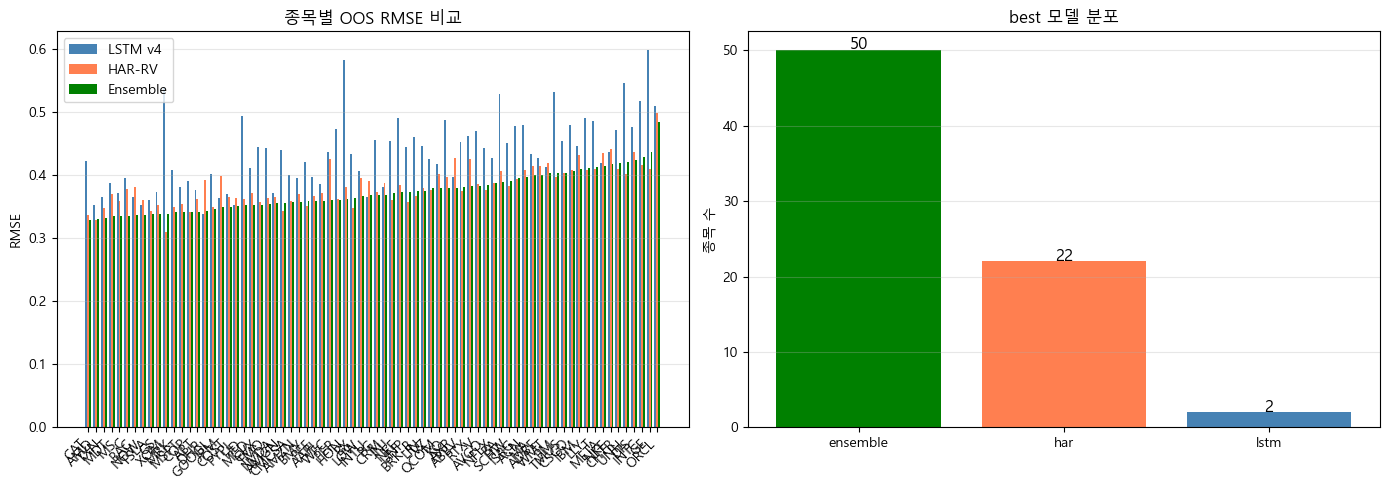

In [7]:
# 7-1. 종목별 RMSE 비교 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 비교
metrics_sorted = metrics_df.sort_values('rmse_ensemble')
x = np.arange(len(metrics_sorted))
w = 0.25
axes[0].bar(x - w, metrics_sorted['rmse_lstm'], w, label='LSTM v4', color='steelblue')
axes[0].bar(x, metrics_sorted['rmse_har'], w, label='HAR-RV', color='coral')
axes[0].bar(x + w, metrics_sorted['rmse_ensemble'], w, label='Ensemble', color='green')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_sorted['ticker'], rotation=45, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('종목별 OOS RMSE 비교')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# best 모델 분포
ax = axes[1]
best_counts = metrics_df['best'].value_counts()
colors = {'lstm': 'steelblue', 'har': 'coral', 'ensemble': 'green'}
ax.bar(best_counts.index, best_counts.values, color=[colors[b] for b in best_counts.index])
ax.set_ylabel('종목 수')
ax.set_title('best 모델 분포')
for i, v in enumerate(best_counts.values):
    ax.text(i, v + 0.1, f'{v}', ha='center', fontsize=12)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

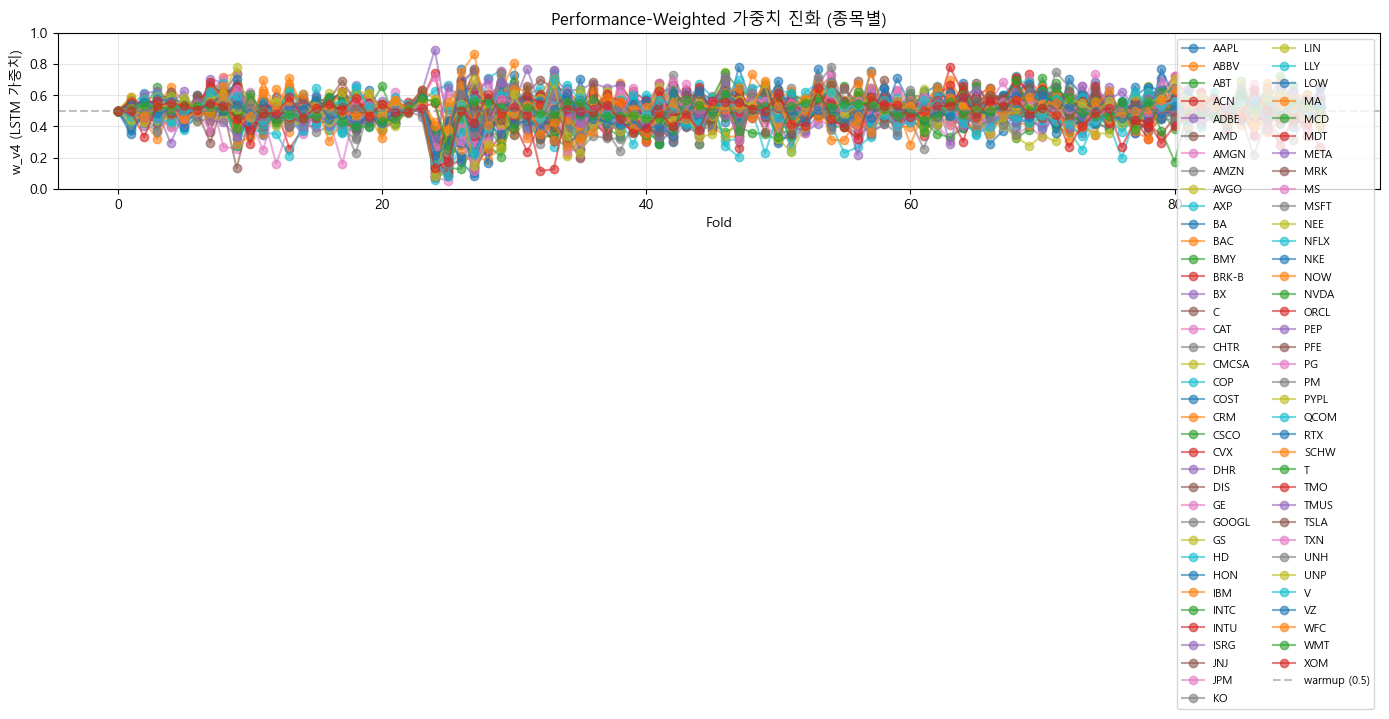

In [8]:
# 7-2. 가중치 진화 (시간 축)
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in weights_summary['ticker'].unique():
    df_t = weights_summary[weights_summary['ticker'] == ticker].sort_values('fold')
    ax.plot(df_t['fold'], df_t['w_v4'], marker='o', alpha=0.6, label=ticker)
ax.axhline(0.5, color='gray', ls='--', alpha=0.5, label='warmup (0.5)')
ax.set_xlabel('Fold')
ax.set_ylabel('w_v4 (LSTM 가중치)')
ax.set_title('Performance-Weighted 가중치 진화 (종목별)')
ax.legend(loc='upper right', ncol=2, fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUT_DIR / 'weights_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

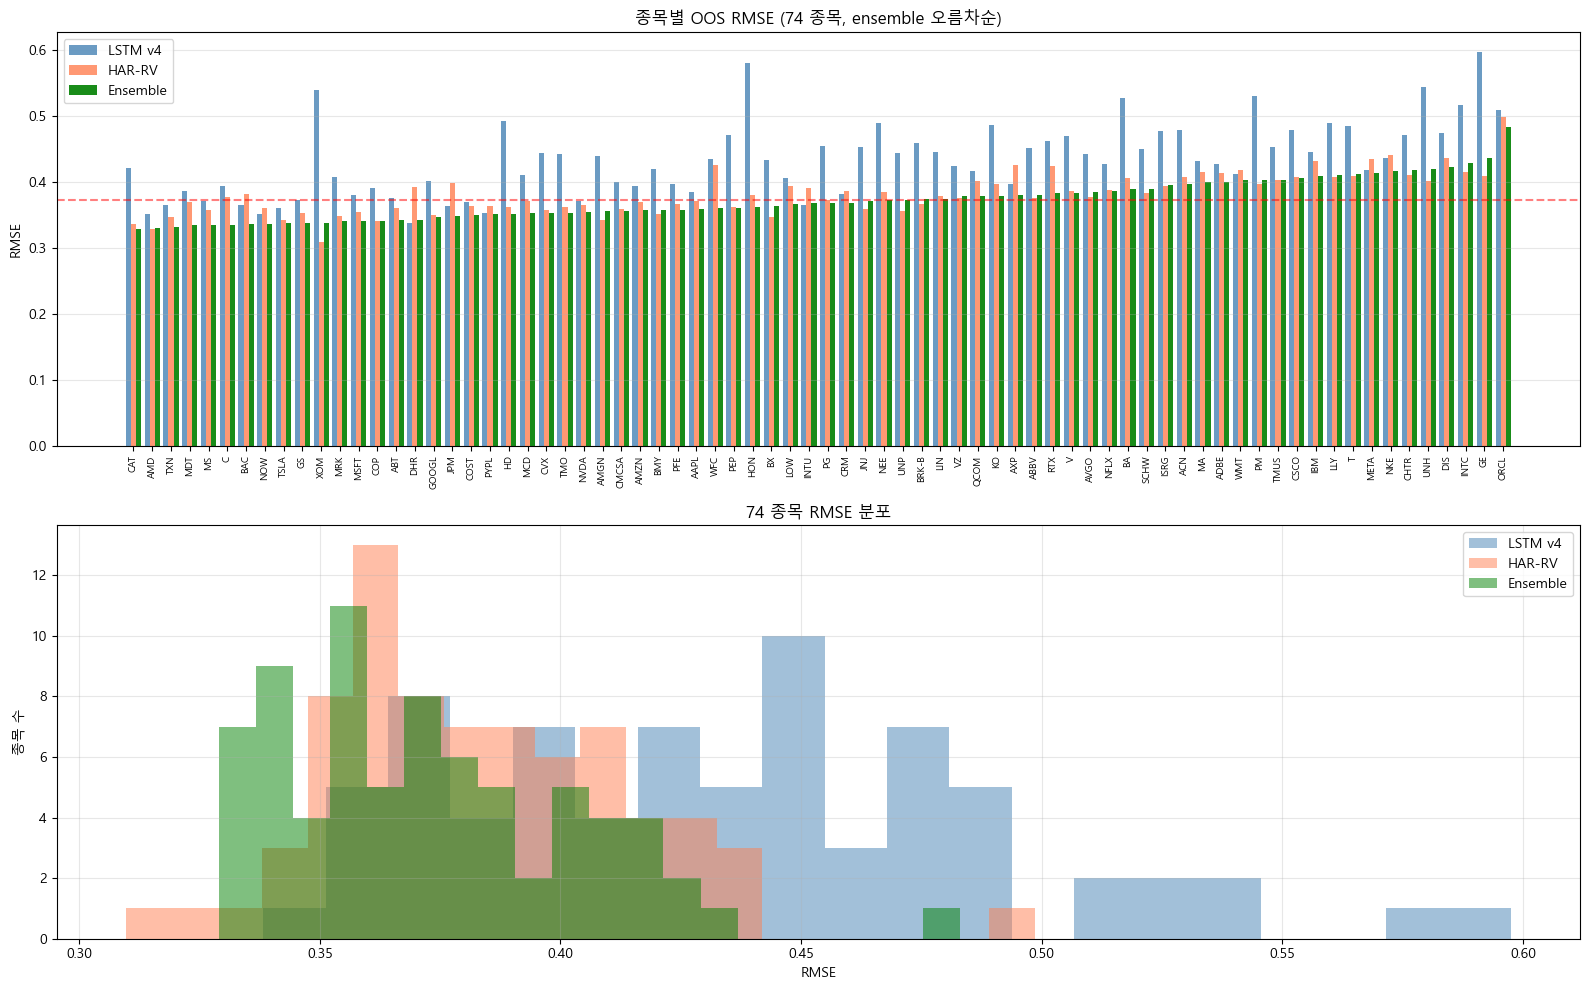


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\outputs\03_ensemble\rmse_comparison_full.png


In [9]:
# === 코드 1. 종목별 RMSE 비교 + 분포 ===
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

ens = pd.read_csv(DATA_DIR / 'ensemble_predictions_top50.csv', parse_dates=['date'])

def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))

metrics = []
for tk, df in ens.groupby('ticker'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) == 0: continue
    metrics.append({
        'ticker': tk, 'n': len(v),
        'rmse_lstm': rmse(v['y_pred_lstm'], v['y_true']),
        'rmse_har':  rmse(v['y_pred_har'],  v['y_true']),
        'rmse_ens':  rmse(v['y_pred_ensemble'], v['y_true']),
        'mean_w_v4': df['w_v4'].mean(),
    })
m = pd.DataFrame(metrics)
m['best'] = m[['rmse_lstm', 'rmse_har', 'rmse_ens']].idxmin(axis=1).str.replace('rmse_', '')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# (a) ticker별 RMSE 비교 (sorted)
ms = m.sort_values('rmse_ens').reset_index(drop=True)
x = np.arange(len(ms))
w = 0.27
axes[0].bar(x - w, ms['rmse_lstm'], w, label='LSTM v4', color='steelblue', alpha=0.8)
axes[0].bar(x,     ms['rmse_har'],  w, label='HAR-RV',  color='coral', alpha=0.8)
axes[0].bar(x + w, ms['rmse_ens'],  w, label='Ensemble', color='green', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ms['ticker'], rotation=90, fontsize=7)
axes[0].set_ylabel('RMSE')
axes[0].set_title('종목별 OOS RMSE (74 종목, ensemble 오름차순)')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(m['rmse_ens'].mean(), color='red', ls='--', alpha=0.5,
                label=f'ens 평균={m["rmse_ens"].mean():.3f}')

# (b) 분포 히스토그램
axes[1].hist(m['rmse_lstm'], bins=20, alpha=0.5, label='LSTM v4', color='steelblue')
axes[1].hist(m['rmse_har'],  bins=20, alpha=0.5, label='HAR-RV',  color='coral')
axes[1].hist(m['rmse_ens'],  bins=20, alpha=0.5, label='Ensemble', color='green')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('종목 수')
axes[1].set_title('74 종목 RMSE 분포')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_comparison_full.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n저장: {OUT_DIR / "rmse_comparison_full.png"}')

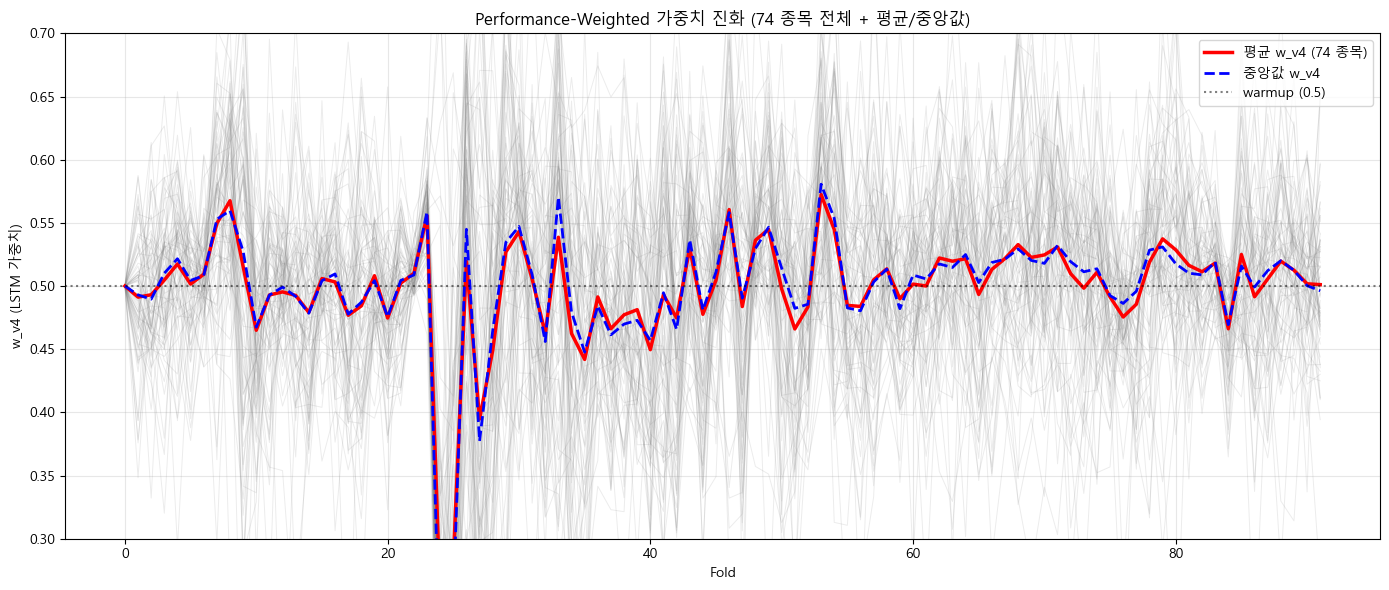


=== 가중치 통계 ===
  fold 0 (warmup): w_v4 = 0.500
  fold 별 평균 w_v4 표준편차: 0.0448
  마지막 fold 평균 w_v4: 0.501


In [10]:
# === 코드 2. 가중치 진화 ===
fig, ax = plt.subplots(figsize=(14, 6))

# 종목별 fold 별 w_v4 평균 (이미 fold 내 동일값이지만 안전)
weights = ens.groupby(['ticker', 'fold']).agg(
    w_v4=('w_v4', 'first'),
    date=('date', 'first'),
).reset_index()

# 모든 종목 (얇은 회색)
for tk in weights['ticker'].unique():
    df_t = weights[weights['ticker'] == tk].sort_values('fold')
    ax.plot(df_t['fold'], df_t['w_v4'], color='gray', alpha=0.15, lw=0.7)

# 평균 (강조)
mean_w = weights.groupby('fold')['w_v4'].mean()
median_w = weights.groupby('fold')['w_v4'].median()
ax.plot(mean_w.index, mean_w.values, color='red', lw=2.5, label='평균 w_v4 (74 종목)')
ax.plot(median_w.index, median_w.values, color='blue', lw=2, ls='--', label='중앙값 w_v4')
ax.axhline(0.5, color='black', ls=':', alpha=0.5, label='warmup (0.5)')

ax.set_xlabel('Fold')
ax.set_ylabel('w_v4 (LSTM 가중치)')
ax.set_title('Performance-Weighted 가중치 진화 (74 종목 전체 + 평균/중앙값)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_ylim(0.3, 0.7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'weights_evolution_full.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n=== 가중치 통계 ===')
print(f'  fold 0 (warmup): w_v4 = {weights[weights["fold"]==0]["w_v4"].mean():.3f}')
print(f'  fold 별 평균 w_v4 표준편차: {mean_w.std():.4f}')
print(f'  마지막 fold 평균 w_v4: {mean_w.iloc[-1]:.3f}')

c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\scripts\universe.py:439: SyntaxWarning: invalid escape sequence '\$'
  """이중상장 종목 통합: secondary 제거, primary 시총 유지.


Wikipedia 에서 GICS 섹터 매핑 조회 중...


c:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\scripts\universe.py:78: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]
C:\Users\gorhk\AppData\Local\Temp\ipykernel_41784\3144181189.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_box, labels=sector_order, vert=False)


Wikipedia 섹터 매핑 종목 수: 503
샘플: {'MMM': 'Industrials', 'AOS': 'Industrials', 'ABT': 'Health Care', 'ABBV': 'Health Care', 'ACN': 'Information Technology'}

매핑된 종목: 74/74

=== 섹터별 종목 분포 ===
sector
Information Technology    16
Health Care               13
Financials                13
Communication Services     9
Consumer Discretionary     6
Industrials                6
Consumer Staples           6
Energy                     3
Materials                  1
Utilities                  1
Name: count, dtype: int64

=== 섹터별 평균 RMSE ===
                         n  rmse_lstm  rmse_har  rmse_ens  mean_w_v4
sector                                                              
Energy                   3   0.457900  0.335800  0.344200   0.484800
Financials              13   0.407500  0.383200  0.361400   0.505500
Consumer Discretionary   6   0.416900  0.380200  0.363900   0.505600
Health Care             13   0.432800  0.371800  0.366400   0.495600
Utilities                1   0.490500  0.384600  0.3727

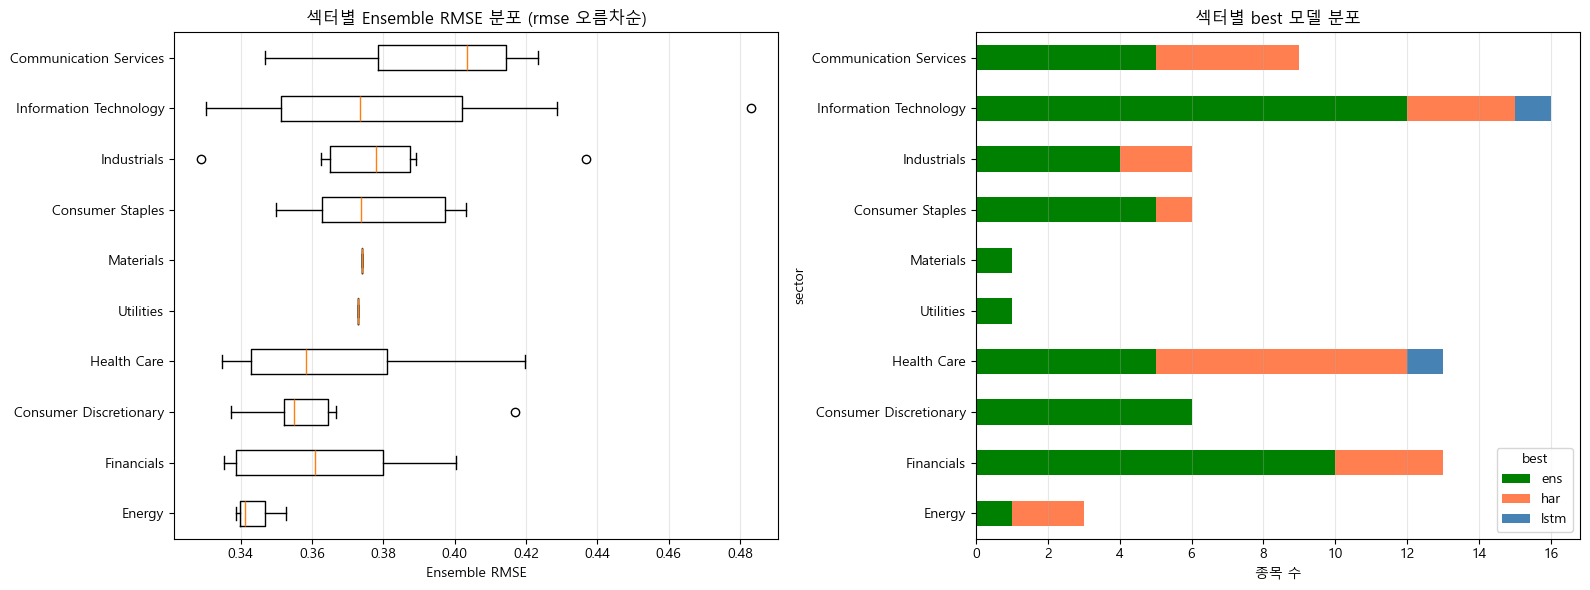

In [18]:
# === 코드 3 정정. 섹터 매핑 + RMSE 분석 ===
import sys
sys.path.insert(0, str(BASE_DIR))
from scripts.universe import fetch_sp500_tables, parse_current_sp500

# 1) Wikipedia 에서 GICS 섹터 정보 가져오기
print('Wikipedia 에서 GICS 섹터 매핑 조회 중...')
tables = fetch_sp500_tables()
df_sp500 = parse_current_sp500(tables[0])
sector_map = dict(zip(df_sp500['ticker'], df_sp500['gics_sector']))

print(f'Wikipedia 섹터 매핑 종목 수: {len(sector_map)}')
print(f'샘플: {dict(list(sector_map.items())[:5])}')

# 2) m DataFrame 에 섹터 적용
m['sector'] = m['ticker'].map(sector_map).fillna('Unknown')

mapped = (m['sector'] != 'Unknown').sum()
print(f'\n매핑된 종목: {mapped}/{len(m)}')
unmapped = m[m['sector'] == 'Unknown']['ticker'].tolist()
if unmapped:
    print(f'매핑 실패 종목 ({len(unmapped)}개): {unmapped}')

print(f'\n=== 섹터별 종목 분포 ===')
print(m['sector'].value_counts())

# 3) 섹터별 평균
sector_metrics = m[m['sector'] != 'Unknown'].groupby('sector').agg(
    n=('ticker', 'count'),
    rmse_lstm=('rmse_lstm', 'mean'),
    rmse_har=('rmse_har', 'mean'),
    rmse_ens=('rmse_ens', 'mean'),
    mean_w_v4=('mean_w_v4', 'mean'),
).round(4).sort_values('rmse_ens')

print('\n=== 섹터별 평균 RMSE ===')
print(sector_metrics.to_string())

# 4) 시각화 — 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sector_order = sector_metrics.index.tolist()

# (a) ensemble RMSE 박스플롯
data_box = [m[m['sector']==s]['rmse_ens'].values for s in sector_order]
axes[0].boxplot(data_box, labels=sector_order, vert=False)
axes[0].set_xlabel('Ensemble RMSE')
axes[0].set_title('섹터별 Ensemble RMSE 분포 (rmse 오름차순)')
axes[0].grid(alpha=0.3, axis='x')

# (b) 섹터별 best 모델 분포
sector_best = pd.crosstab(m[m['sector'] != 'Unknown']['sector'], m[m['sector'] != 'Unknown']['best'])
sector_best = sector_best.reindex(sector_order)
sector_best.plot(kind='barh', stacked=True, ax=axes[1],
                color={'lstm': 'steelblue', 'har': 'coral', 'ens': 'green'})
axes[1].set_xlabel('종목 수')
axes[1].set_title('섹터별 best 모델 분포')
axes[1].legend(title='best')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUT_DIR / 'sector_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# === (추가, 선택) daily_panel.csv 의 gics_sector 갱신 ===
panel_path = DATA_DIR / 'daily_panel.csv'
panel_full = pd.read_csv(panel_path, parse_dates=['date'])
panel_full['gics_sector'] = panel_full['ticker'].map(sector_map).fillna('Unknown')
panel_full.to_csv(panel_path, index=False)
print(f'daily_panel.csv 의 gics_sector 갱신 완료')
print(panel_full['gics_sector'].value_counts())

daily_panel.csv 의 gics_sector 갱신 완료
gics_sector
Information Technology    52336
Health Care               42522
Financials                41892
Communication Services    29439
Consumer Discretionary    19626
Industrials               19626
Consumer Staples          19626
Energy                     9813
Materials                  3271
Utilities                  3271
Name: count, dtype: int64


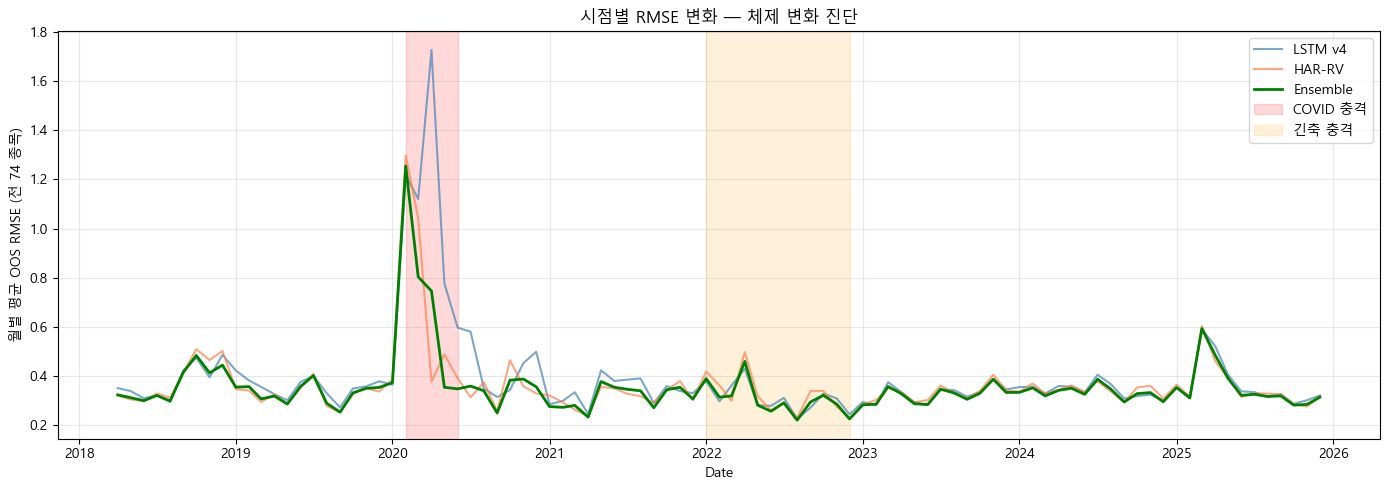


=== 체제별 RMSE ===
  COVID 직전 (2019-2020-01): ens = 0.3336
  COVID 충격 (2020-02~06):    ens = 0.7014
  긴축 (2022 전체):            ens = 0.3052
  최근 (2024-2025):            ens = 0.3462


In [12]:
# === 코드 4. 시점별 RMSE (월별 rolling) ===
# 모든 종목 합쳐서 월별 평균 RMSE
ens['month'] = ens['date'].dt.to_period('M')
monthly = []
for month, df in ens.groupby('month'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) == 0: continue
    monthly.append({
        'month': month.to_timestamp(),
        'n': len(v),
        'rmse_lstm': rmse(v['y_pred_lstm'], v['y_true']),
        'rmse_har':  rmse(v['y_pred_har'],  v['y_true']),
        'rmse_ens':  rmse(v['y_pred_ensemble'], v['y_true']),
    })
mo = pd.DataFrame(monthly)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mo['month'], mo['rmse_lstm'], label='LSTM v4', color='steelblue', alpha=0.7)
ax.plot(mo['month'], mo['rmse_har'],  label='HAR-RV',  color='coral', alpha=0.7)
ax.plot(mo['month'], mo['rmse_ens'],  label='Ensemble', color='green', lw=2)

# 체제 변화 영역 표시
ax.axvspan(pd.Timestamp('2020-02'), pd.Timestamp('2020-06'), alpha=0.15, color='red', label='COVID 충격')
ax.axvspan(pd.Timestamp('2022-01'), pd.Timestamp('2022-12'), alpha=0.15, color='orange', label='긴축 충격')

ax.set_xlabel('Date')
ax.set_ylabel('월별 평균 OOS RMSE (전 74 종목)')
ax.set_title('시점별 RMSE 변화 — 체제 변화 진단')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n=== 체제별 RMSE ===')
print(f'  COVID 직전 (2019-2020-01): ens = {mo[(mo["month"] >= "2019-01") & (mo["month"] < "2020-02")]["rmse_ens"].mean():.4f}')
print(f'  COVID 충격 (2020-02~06):    ens = {mo[(mo["month"] >= "2020-02") & (mo["month"] <= "2020-06")]["rmse_ens"].mean():.4f}')
print(f'  긴축 (2022 전체):            ens = {mo[(mo["month"] >= "2022-01") & (mo["month"] <= "2022-12")]["rmse_ens"].mean():.4f}')
print(f'  최근 (2024-2025):            ens = {mo[(mo["month"] >= "2024-01")]["rmse_ens"].mean():.4f}')

=== DM 검정 결과 (Ensemble 우위, 5% 유의) ===
  vs LSTM v4: 12/74 종목 우위
  vs HAR-RV : 17/74 종목 우위


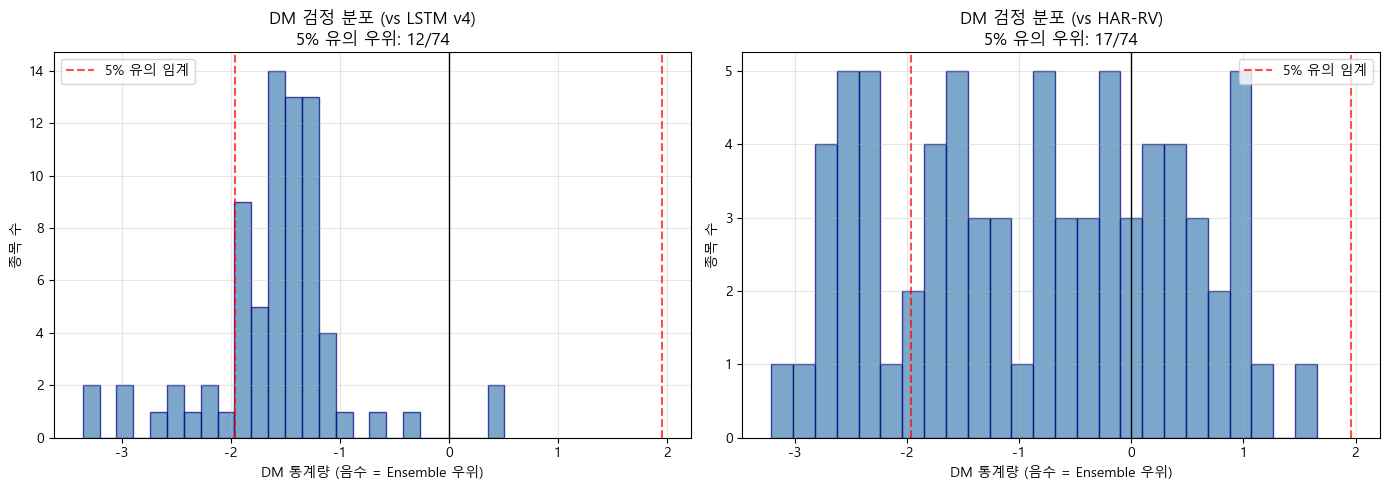

In [13]:
# === 코드 5. DM 검정 (vs LSTM, vs HAR) ===
from scipy import stats

def dm_test(e1, e2, h=21):
    """Diebold-Mariano test (squared error loss).
    e1, e2: forecast errors of two models
    h: forecast horizon
    음수 → 1번이 우위 (오차 작음), 양수 → 2번이 우위
    """
    d = e1**2 - e2**2
    n = len(d)
    d_mean = d.mean()
    # HAC variance (Newey-West with lag h-1)
    gamma = [np.cov(d[:n-k], d[k:], ddof=0)[0,1] if k > 0 else d.var(ddof=0) for k in range(h)]
    var = (gamma[0] + 2 * sum((1 - k/h) * gamma[k] for k in range(1, h))) / n
    if var <= 0:
        return np.nan, np.nan
    dm = d_mean / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(dm)))
    return dm, p

# 종목별 DM
dm_results = []
for tk, df in ens.groupby('ticker'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) < 100: continue
    err_ens = (v['y_pred_ensemble'] - v['y_true']).values
    err_lstm = (v['y_pred_lstm'] - v['y_true']).values
    err_har = (v['y_pred_har'] - v['y_true']).values
    dm_lstm, p_lstm = dm_test(err_ens, err_lstm)
    dm_har, p_har = dm_test(err_ens, err_har)
    dm_results.append({
        'ticker': tk,
        'dm_vs_lstm': dm_lstm, 'p_vs_lstm': p_lstm,
        'dm_vs_har':  dm_har,  'p_vs_har':  p_har,
    })
dm_df = pd.DataFrame(dm_results)

# 5% 유의 우위 종목 (Ensemble 우위 = dm < 0)
sig_lstm = ((dm_df['dm_vs_lstm'] < 0) & (dm_df['p_vs_lstm'] < 0.05)).sum()
sig_har  = ((dm_df['dm_vs_har']  < 0) & (dm_df['p_vs_har']  < 0.05)).sum()
print(f'=== DM 검정 결과 (Ensemble 우위, 5% 유의) ===')
print(f'  vs LSTM v4: {sig_lstm}/{len(dm_df)} 종목 우위')
print(f'  vs HAR-RV : {sig_har}/{len(dm_df)} 종목 우위')

# 시각화 — DM 통계량 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, name, sig in [(axes[0], 'dm_vs_lstm', 'vs LSTM v4', sig_lstm),
                             (axes[1], 'dm_vs_har', 'vs HAR-RV', sig_har)]:
    ax.hist(dm_df[col], bins=25, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.axvline(0, color='black', ls='-', lw=1)
    ax.axvline(-1.96, color='red', ls='--', alpha=0.7, label='5% 유의 임계')
    ax.axvline(1.96, color='red', ls='--', alpha=0.7)
    ax.set_xlabel('DM 통계량 (음수 = Ensemble 우위)')
    ax.set_ylabel('종목 수')
    ax.set_title(f'DM 검정 분포 ({name})\n5% 유의 우위: {sig}/{len(dm_df)}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'dm_test.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# === 코드 6 정정. Phase 1.5 v8 의 GOOGL 결과와 비교 ===
phase15_dir = BASE_DIR.parent / 'Phase1_5_Volatility'
phase15_csv = phase15_dir / 'results' / 'lstm_ensemble' / 'ensemble_comparison.csv'

if phase15_csv.exists():
    p15_df = pd.read_csv(phase15_csv)
    
    # Phase 1.5 의 7 종목 메트릭
    print('=== Phase 1.5 v8 (7 종목) 메트릭 요약 ===')
    print(p15_df.pivot_table(index='ticker', columns='model', values='rmse').round(4).to_string())
    
    # Phase 1.5 ↔ Phase 2 일치 종목 비교
    common_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']  # Phase 2 universe 와 겹침
    p15_googl = p15_df[(p15_df['ticker'] == 'GOOGL') & (p15_df['model'] == 'performance')]
    
    if len(p15_googl) > 0:
        p15_googl_rmse = p15_googl['rmse'].iloc[0]
        p15_googl_qlike = p15_googl['qlike'].iloc[0]
        p15_googl_r2 = p15_googl['r2_train_mean'].iloc[0]
        p15_googl_std = p15_googl['pred_std_ratio'].iloc[0]
        
        # Phase 2 의 GOOGL
        p2_googl = ens[ens['ticker'] == 'GOOGL'].dropna(subset=['y_true', 'y_pred_ensemble'])
        p2_googl_rmse = np.sqrt(((p2_googl['y_pred_ensemble'] - p2_googl['y_true']) ** 2).mean())
        
        print('\n=== GOOGL 비교 (Phase 1.5 v8 ↔ Phase 2) ===')
        print(f'  Phase 1.5 v8 (7 종목): performance RMSE = {p15_googl_rmse:.4f}')
        print(f'  Phase 2     (74 종목): ensemble    RMSE = {p2_googl_rmse:.4f}')
        print(f'  차이: {(p2_googl_rmse - p15_googl_rmse) / p15_googl_rmse * 100:+.1f}%')
        print(f'\n  Phase 1.5 의 다른 메트릭 (참고):')
        print(f'    QLIKE          : {p15_googl_qlike:.4f}')
        print(f'    R²_train_mean  : {p15_googl_r2:.4f}')
        print(f'    pred_std_ratio : {p15_googl_std:.4f}')
    else:
        print('Phase 1.5 의 GOOGL performance 모델 결과 없음')
else:
    print(f'Phase 1.5 csv 미발견: {phase15_csv}')
    print('(Phase 1.5 의 7 종목과 Phase 2 의 universe 가 겹치지 않을 가능성)')

# === 추가: Phase 2 의 핵심 종목 자체 진단 ===
print('\n=== Phase 2 의 Phase 1.5 일치 종목 (자체 진단) ===')
for tk in ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'WMT']:
    if tk in ens['ticker'].values:
        v = ens[ens['ticker'] == tk].dropna(subset=['y_true', 'y_pred_ensemble'])
        rmse_e = np.sqrt(((v['y_pred_ensemble'] - v['y_true']) ** 2).mean())
        print(f'  {tk}: n={len(v)}, RMSE ens = {rmse_e:.4f}')

=== Phase 1.5 v8 (7 종목) 메트릭 요약 ===
model   asset_specific      har      ivw  lstm_v4  performance   simple
ticker                                                                 
DIA           0.290500 0.306000 0.290600 0.296300     0.287400 0.290500
EEM           0.255400 0.266200 0.255400 0.254600     0.256000 0.255500
GOOGL         0.279000 0.285000 0.279000 0.282700     0.278500 0.279000
QQQ           0.285800 0.292000 0.285800 0.292100     0.286200 0.285800
SPY           0.317200 0.323900 0.317200 0.320800     0.314800 0.317200
WMT           0.325700 0.326900 0.325600 0.336400     0.324600 0.325800
XLF           0.307300 0.316400 0.307300 0.308800     0.306000 0.307300

=== GOOGL 비교 (Phase 1.5 v8 ↔ Phase 2) ===
  Phase 1.5 v8 (7 종목): performance RMSE = 0.2785
  Phase 2     (74 종목): ensemble    RMSE = 0.3467
  차이: +24.5%

  Phase 1.5 의 다른 메트릭 (참고):
    QLIKE          : 0.2183
    R²_train_mean  : -0.1176
    pred_std_ratio : 0.4623

=== Phase 2 의 Phase 1.5 일치 종목 (자체 진단) ===
  AAPL:

In [25]:
# === Phase 2 의 OOS 를 2021-05 이후로 제한 (Phase 1.5 와 fair) ===
mask = ens['date'] >= '2021-05-01'
ens_late = ens[mask]

phase15_perf = {
    'DIA': 0.2874, 'EEM': 0.2560, 'GOOGL': 0.2785,
    'QQQ': 0.2862, 'SPY': 0.3148, 'WMT': 0.3246, 'XLF': 0.3060
}
print('=== Phase 2 의 2021-05 이후 OOS — Phase 1.5 와 fair 비교 ===')
for tk, p15_rmse in phase15_perf.items():
    if tk not in ens_late['ticker'].values: continue
    v = ens_late[ens_late['ticker'] == tk].dropna(subset=['y_true', 'y_pred_ensemble'])
    if len(v) == 0: continue
    rmse_p2 = np.sqrt(((v['y_pred_ensemble'] - v['y_true']) ** 2).mean())
    print(f'  {tk}: Phase 1.5={p15_rmse:.4f}, Phase 2 (2021+)={rmse_p2:.4f}, 차이={rmse_p2/p15_rmse-1:+.1%}')

=== Phase 2 의 2021-05 이후 OOS — Phase 1.5 와 fair 비교 ===
  GOOGL: Phase 1.5=0.2785, Phase 2 (2021+)=0.2961, 차이=+6.3%
  WMT: Phase 1.5=0.3246, Phase 2 (2021+)=0.3654, 차이=+12.6%


In [15]:
# === 코드 7. QLIKE 메트릭 ===
def qlike(y_true_logrv, y_pred_logrv, eps=1e-12):
    """Patton (2011) QLIKE: variance domain 변환 후 비대칭 손실."""
    sig2_true = np.exp(2 * y_true_logrv)
    sig2_pred = np.exp(2 * y_pred_logrv).clip(min=eps)
    return np.mean(sig2_true / sig2_pred - np.log(sig2_true / sig2_pred) - 1)

qlike_results = []
for tk, df in ens.groupby('ticker'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) == 0: continue
    qlike_results.append({
        'ticker': tk,
        'qlike_lstm': qlike(v['y_true'].values, v['y_pred_lstm'].values),
        'qlike_har':  qlike(v['y_true'].values, v['y_pred_har'].values),
        'qlike_ens':  qlike(v['y_true'].values, v['y_pred_ensemble'].values),
    })
q = pd.DataFrame(qlike_results)
q['best_qlike'] = q[['qlike_lstm', 'qlike_har', 'qlike_ens']].idxmin(axis=1).str.replace('qlike_', '')

print('=== 평균 QLIKE (낮을수록 좋음, 변동성 예측 학술 표준) ===')
print(f'  LSTM v4    : {q["qlike_lstm"].mean():.4f}  (median {q["qlike_lstm"].median():.4f})')
print(f'  HAR-RV     : {q["qlike_har"].mean():.4f}   (median {q["qlike_har"].median():.4f})')
print(f'  Ensemble   : {q["qlike_ens"].mean():.4f}   (median {q["qlike_ens"].median():.4f})')

print(f'\n=== best by QLIKE ===')
print(q['best_qlike'].value_counts())

# Phase 1.5 v8 비교 (참고)
print(f'\n=== Phase 1.5 v8 (7 종목) QLIKE 평균 ===')
print(f'  LSTM 0.279 / HAR 0.265 / Ensemble 0.258')

=== 평균 QLIKE (낮을수록 좋음, 변동성 예측 학술 표준) ===
  LSTM v4    : 0.4295  (median 0.4207)
  HAR-RV     : 0.5074   (median 0.4958)
  Ensemble   : 0.4191   (median 0.4255)

=== best by QLIKE ===
best_qlike
ens     47
lstm    27
Name: count, dtype: int64

=== Phase 1.5 v8 (7 종목) QLIKE 평균 ===
  LSTM 0.279 / HAR 0.265 / Ensemble 0.258


=== fold 별 ensemble 우위 빈도 (음수 = ensemble 우위) ===
  vs LSTM: ensemble 우위 3691/6778 fold (54.5%)
  vs HAR : ensemble 우위 4120/6778 fold (60.8%)


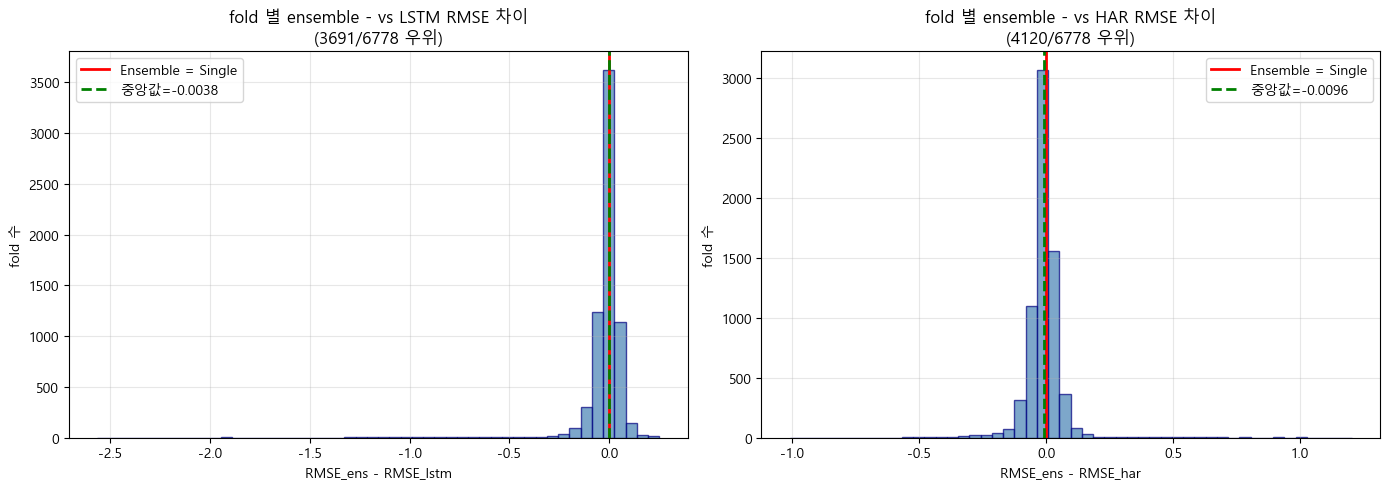

In [16]:
# === 코드 8. fold 별 ensemble 우위 빈도 ===
fold_diff_lstm = []
fold_diff_har = []
for tk, df in ens.groupby('ticker'):
    for fold, fdf in df.groupby('fold'):
        v = fdf.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
        if len(v) == 0: continue
        rmse_l = rmse(v['y_pred_lstm'], v['y_true'])
        rmse_h = rmse(v['y_pred_har'], v['y_true'])
        rmse_e = rmse(v['y_pred_ensemble'], v['y_true'])
        fold_diff_lstm.append(rmse_e - rmse_l)
        fold_diff_har.append(rmse_e - rmse_h)

fold_diff_lstm = np.array(fold_diff_lstm)
fold_diff_har = np.array(fold_diff_har)

print(f'=== fold 별 ensemble 우위 빈도 (음수 = ensemble 우위) ===')
print(f'  vs LSTM: ensemble 우위 {(fold_diff_lstm < 0).sum()}/{len(fold_diff_lstm)} fold ({(fold_diff_lstm<0).mean()*100:.1f}%)')
print(f'  vs HAR : ensemble 우위 {(fold_diff_har  < 0).sum()}/{len(fold_diff_har)} fold ({(fold_diff_har <0).mean()*100:.1f}%)')

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, diff, name in [(axes[0], fold_diff_lstm, 'vs LSTM'), (axes[1], fold_diff_har, 'vs HAR')]:
    ax.hist(diff, bins=50, color='steelblue', alpha=0.7, edgecolor='navy')
    ax.axvline(0, color='red', ls='-', lw=2, label='Ensemble = Single')
    ax.axvline(np.median(diff), color='green', ls='--', lw=2, label=f'중앙값={np.median(diff):.4f}')
    ax.set_xlabel(f'RMSE_ens - RMSE_{name.split()[-1].lower()}')
    ax.set_ylabel('fold 수')
    ax.set_title(f'fold 별 ensemble - {name} RMSE 차이\n({(diff<0).sum()}/{len(diff)} 우위)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== BL P 행렬 양극단 RANK 일치도 ===
  저변동성 30% (long) 일치도 : 0.634  (랜덤 0.30)
  고변동성 30% (short) 일치도: 0.615  (랜덤 0.30)


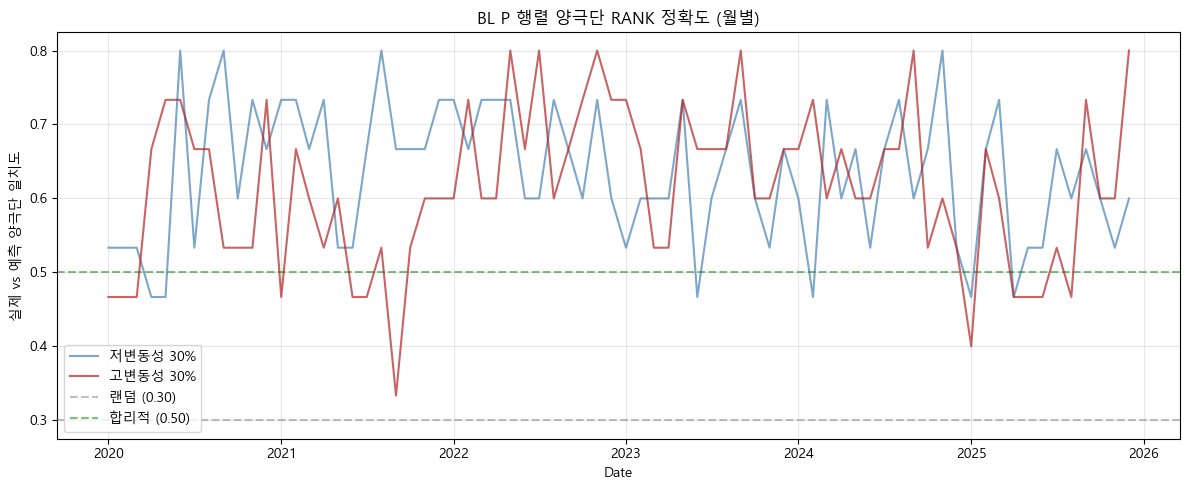

In [22]:
# === 추가 진단 1. BL 양극단 RANK 정확도 ===
# 매월 universe 의 하위 30% (저변동성) / 상위 30% (고변동성) 분류 정확도
import pandas as pd, numpy as np

ens = pd.read_csv(DATA_DIR / 'ensemble_predictions_top50.csv', parse_dates=['date'])
universe = pd.read_csv(DATA_DIR / 'universe_top50_history.csv', parse_dates=['cutoff_date'])

# 매월 말 기준 (BL 리밸런싱 시점)
ens['month'] = ens['date'].dt.to_period('M')
month_end = ens.groupby(['ticker', 'month']).last().reset_index()
month_end['oos_year'] = month_end['date'].dt.year

results = []
for (year, month), group in month_end.groupby(['oos_year', 'month']):
    # 해당 연도 universe 50 종목 필터
    universe_year = universe[universe['oos_year'] == year]['ticker'].tolist()
    g = group[group['ticker'].isin(universe_year)]
    if len(g) < 30: continue
    
    # 실제 vs 예측 의 양극단 30% 일치도
    n_top = max(int(len(g) * 0.30), 5)
    actual_low = set(g.nsmallest(n_top, 'y_true')['ticker'])
    pred_low = set(g.nsmallest(n_top, 'y_pred_ensemble')['ticker'])
    actual_high = set(g.nlargest(n_top, 'y_true')['ticker'])
    pred_high = set(g.nlargest(n_top, 'y_pred_ensemble')['ticker'])
    
    results.append({
        'year': year, 'month': month.to_timestamp(),
        'overlap_low': len(actual_low & pred_low) / n_top,
        'overlap_high': len(actual_high & pred_high) / n_top,
    })
r = pd.DataFrame(results)
print(f'=== BL P 행렬 양극단 RANK 일치도 ===')
print(f'  저변동성 30% (long) 일치도 : {r["overlap_low"].mean():.3f}  (랜덤 0.30)')
print(f'  고변동성 30% (short) 일치도: {r["overlap_high"].mean():.3f}  (랜덤 0.30)')

# 시각화
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(r['month'], r['overlap_low'], label='저변동성 30%', color='steelblue', alpha=0.7)
ax.plot(r['month'], r['overlap_high'], label='고변동성 30%', color='firebrick', alpha=0.7)
ax.axhline(0.30, color='gray', ls='--', alpha=0.5, label='랜덤 (0.30)')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적 (0.50)')
ax.set_xlabel('Date')
ax.set_ylabel('실제 vs 예측 양극단 일치도')
ax.set_title('BL P 행렬 양극단 RANK 정확도 (월별)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

🔍 양극단 RANK 일치도 — ML Ensemble vs Trailing Baseline

=== 평균 일치도 ===
                              저변동 30%   고변동 30%   평균
  랜덤 (벤치마크)            : 0.300        0.300        0.300
  Trailing vol_21d : 0.579        0.577        0.578
  ML Ensemble (Phase 2)     : 0.634        0.615        0.625

=== ML 우위 (ML - Trailing) ===
  저변동 30%: +0.056  (+9.6%)
  고변동 30%: +0.038  (+6.6%)

=== 월별 ML 우위 빈도 ===
  ML > Trailing (저변동): 43/72 (60%)
  ML > Trailing (고변동): 37/72 (51%)

=== 시기별 비교 (저변동 30% 기준) ===
                  Trailing    ML       ML 우위
  COVID         : 0.583      0.608    +0.025
  긴축 (2022)   : 0.644      0.678    +0.033
  정상기 (그 외): 0.563      0.628    +0.065


C:\Users\gorhk\AppData\Local\Temp\ipykernel_41784\4230546200.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_low, labels=['Trailing', 'ML Ensemble\n(Phase 2)'],
C:\Users\gorhk\AppData\Local\Temp\ipykernel_41784\4230546200.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_high, labels=['Trailing', 'ML Ensemble\n(Phase 2)'],


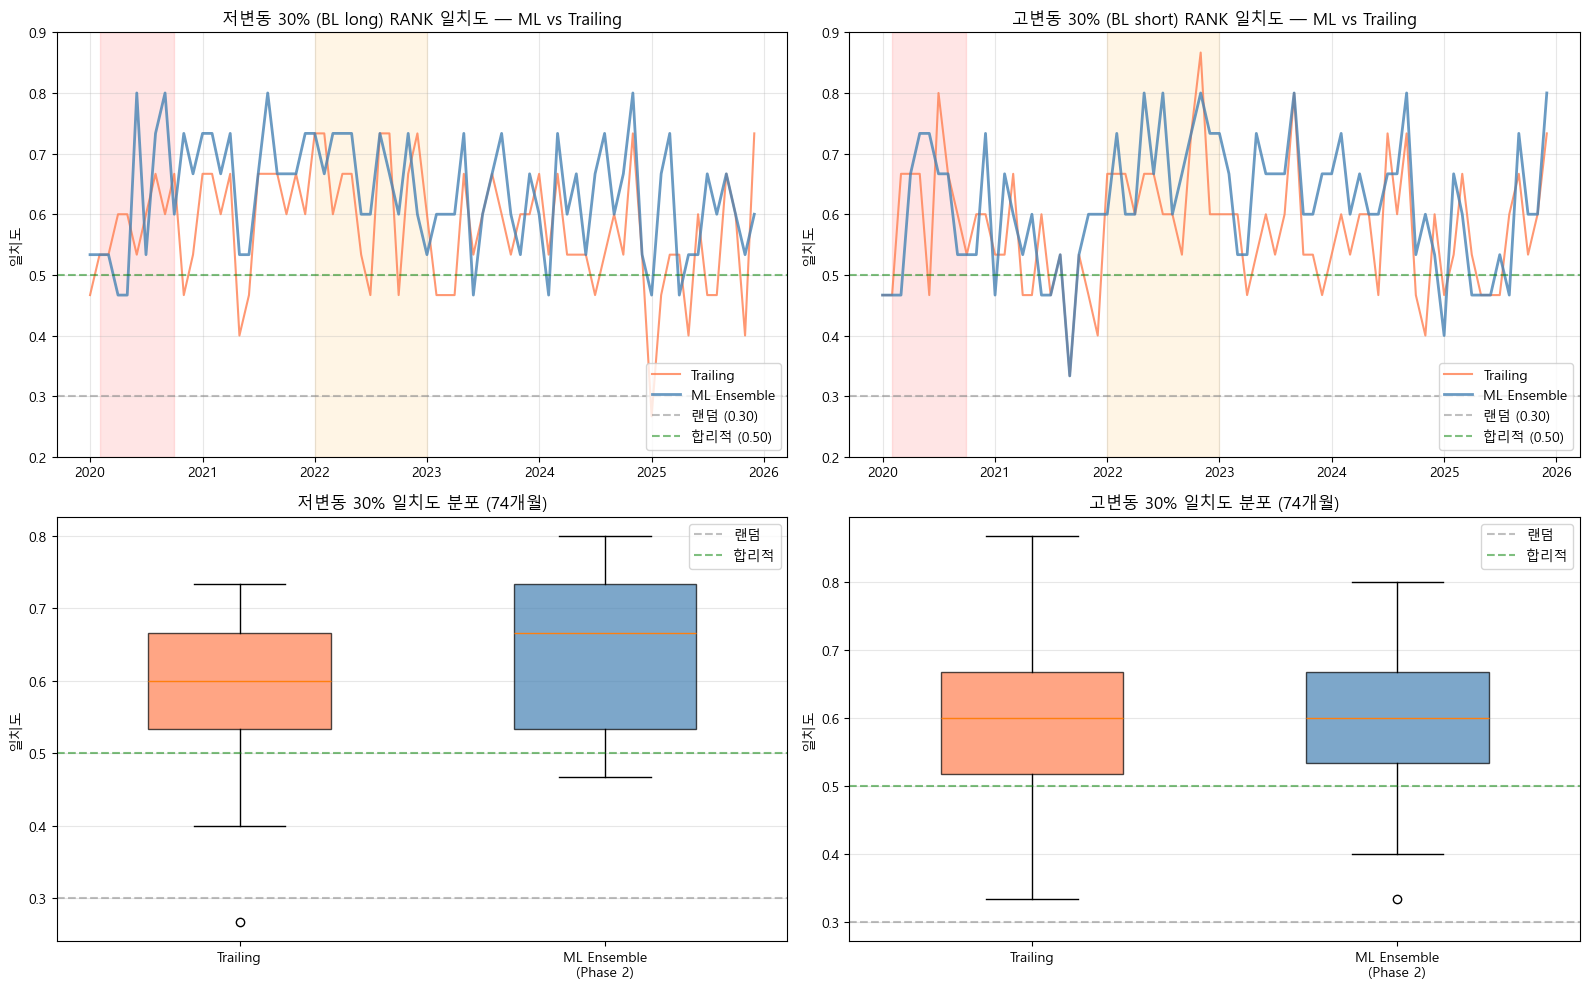


저장:
  CSV: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\data\rank_comparison_ml_vs_trailing.csv
  PNG: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration\outputs\03_ensemble\rank_comparison_ml_vs_trailing.png


In [28]:
# === ML Ensemble vs Trailing Baseline RANK 정확도 비교 ===
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# 1) 데이터 로드 (이미 ens 가 메모리에 있다면 재로드 불필요)
panel = pd.read_csv(DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
                    usecols=['date', 'ticker', 'vol_21d'])
universe = pd.read_csv(DATA_DIR / 'universe_top50_history.csv', parse_dates=['cutoff_date'])

# 2) ens 의 매월 시점 (BL 리밸런싱 시점) 추출 + trailing vol_21d 매핑
ens['month'] = ens['date'].dt.to_period('M')
month_ends = ens.groupby(['ticker', 'month']).last().reset_index()
month_ends['oos_year'] = month_ends['date'].dt.year

# panel 의 trailing vol_21d 와 결합
panel_lookup = panel.rename(columns={'vol_21d': 'trailing_vol_21d'})
month_ends = month_ends.merge(panel_lookup, on=['date', 'ticker'], how='left')

# 3) 매월 양극단 30% RANK 일치도 계산
results = []
for (year, month), group in month_ends.groupby(['oos_year', 'month']):
    universe_year = universe[universe['oos_year'] == year]['ticker'].tolist()
    g = group[group['ticker'].isin(universe_year)].dropna(
        subset=['y_true', 'y_pred_ensemble', 'trailing_vol_21d']
    )
    if len(g) < 30: continue
    
    n_top = max(int(len(g) * 0.30), 5)
    
    # 실제 (forward 변동성, 정답)
    actual_low = set(g.nsmallest(n_top, 'y_true')['ticker'])
    actual_high = set(g.nlargest(n_top, 'y_true')['ticker'])
    
    # ML 예측 (Phase 2 ensemble)
    ml_low = set(g.nsmallest(n_top, 'y_pred_ensemble')['ticker'])
    ml_high = set(g.nlargest(n_top, 'y_pred_ensemble')['ticker'])
    
    # Trailing baseline (vol_21d 그대로)
    tr_low = set(g.nsmallest(n_top, 'trailing_vol_21d')['ticker'])
    tr_high = set(g.nlargest(n_top, 'trailing_vol_21d')['ticker'])
    
    results.append({
        'year': year, 'month': month.to_timestamp(),
        'n': len(g), 'n_top': n_top,
        'ml_low':       len(actual_low & ml_low) / n_top,
        'ml_high':      len(actual_high & ml_high) / n_top,
        'trailing_low': len(actual_low & tr_low) / n_top,
        'trailing_high':len(actual_high & tr_high) / n_top,
    })
r = pd.DataFrame(results)

# 4) 평균 결과 출력
print('=' * 70)
print('🔍 양극단 RANK 일치도 — ML Ensemble vs Trailing Baseline')
print('=' * 70)
print(f'\n=== 평균 일치도 ===')
print(f'                              저변동 30%   고변동 30%   평균')
print(f'  랜덤 (벤치마크)            : 0.300        0.300        0.300')
print(f'  Trailing vol_21d : {r["trailing_low"].mean():.3f}        {r["trailing_high"].mean():.3f}        {(r["trailing_low"].mean()+r["trailing_high"].mean())/2:.3f}')
print(f'  ML Ensemble (Phase 2)     : {r["ml_low"].mean():.3f}        {r["ml_high"].mean():.3f}        {(r["ml_low"].mean()+r["ml_high"].mean())/2:.3f}')

diff_low = r['ml_low'].mean() - r['trailing_low'].mean()
diff_high = r['ml_high'].mean() - r['trailing_high'].mean()
print(f'\n=== ML 우위 (ML - Trailing) ===')
print(f'  저변동 30%: {diff_low:+.3f}  ({diff_low/r["trailing_low"].mean()*100:+.1f}%)')
print(f'  고변동 30%: {diff_high:+.3f}  ({diff_high/r["trailing_high"].mean()*100:+.1f}%)')

# 월별 ML 우위 빈도
print(f'\n=== 월별 ML 우위 빈도 ===')
print(f'  ML > Trailing (저변동): {(r["ml_low"] > r["trailing_low"]).sum()}/{len(r)} ({(r["ml_low"] > r["trailing_low"]).mean()*100:.0f}%)')
print(f'  ML > Trailing (고변동): {(r["ml_high"] > r["trailing_high"]).sum()}/{len(r)} ({(r["ml_high"] > r["trailing_high"]).mean()*100:.0f}%)')

# 시기별 분석
covid_mask = (r['month'] >= '2020-02-01') & (r['month'] <= '2020-09-30')
tightening_mask = (r['month'] >= '2022-01-01') & (r['month'] <= '2022-12-31')

print(f'\n=== 시기별 비교 (저변동 30% 기준) ===')
print(f'                  Trailing    ML       ML 우위')
print(f'  COVID         : {r[covid_mask]["trailing_low"].mean():.3f}      {r[covid_mask]["ml_low"].mean():.3f}    {(r[covid_mask]["ml_low"].mean()-r[covid_mask]["trailing_low"].mean()):+.3f}')
print(f'  긴축 (2022)   : {r[tightening_mask]["trailing_low"].mean():.3f}      {r[tightening_mask]["ml_low"].mean():.3f}    {(r[tightening_mask]["ml_low"].mean()-r[tightening_mask]["trailing_low"].mean()):+.3f}')
print(f'  정상기 (그 외): {r[~(covid_mask|tightening_mask)]["trailing_low"].mean():.3f}      {r[~(covid_mask|tightening_mask)]["ml_low"].mean():.3f}    {(r[~(covid_mask|tightening_mask)]["ml_low"].mean()-r[~(covid_mask|tightening_mask)]["trailing_low"].mean()):+.3f}')

# 5) 시각화 — 시간 시계열 + 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) 저변동 30% 시간 시계열 (ML vs Trailing)
ax = axes[0, 0]
ax.plot(r['month'], r['trailing_low'], label='Trailing', color='coral', alpha=0.8)
ax.plot(r['month'], r['ml_low'], label='ML Ensemble', color='steelblue', alpha=0.8, lw=2)
ax.axhline(0.30, color='gray', ls='--', alpha=0.5, label='랜덤 (0.30)')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적 (0.50)')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-09-30'), alpha=0.1, color='red')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), alpha=0.1, color='orange')
ax.set_title('저변동 30% (BL long) RANK 일치도 — ML vs Trailing')
ax.set_ylabel('일치도')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(0.2, 0.9)

# (b) 고변동 30% 시간 시계열
ax = axes[0, 1]
ax.plot(r['month'], r['trailing_high'], label='Trailing', color='coral', alpha=0.8)
ax.plot(r['month'], r['ml_high'], label='ML Ensemble', color='steelblue', alpha=0.8, lw=2)
ax.axhline(0.30, color='gray', ls='--', alpha=0.5, label='랜덤 (0.30)')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적 (0.50)')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-09-30'), alpha=0.1, color='red')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), alpha=0.1, color='orange')
ax.set_title('고변동 30% (BL short) RANK 일치도 — ML vs Trailing')
ax.set_ylabel('일치도')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(0.2, 0.9)

# (c) 박스플롯 — 분포 비교 (저변동)
ax = axes[1, 0]
data_low = [r['trailing_low'], r['ml_low']]
bp = ax.boxplot(data_low, labels=['Trailing', 'ML Ensemble\n(Phase 2)'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.axhline(0.30, color='gray', ls='--', alpha=0.5, label='랜덤')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적')
ax.set_title('저변동 30% 일치도 분포 (74개월)')
ax.set_ylabel('일치도')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# (d) 박스플롯 — 고변동
ax = axes[1, 1]
data_high = [r['trailing_high'], r['ml_high']]
bp = ax.boxplot(data_high, labels=['Trailing', 'ML Ensemble\n(Phase 2)'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.axhline(0.30, color='gray', ls='--', alpha=0.5, label='랜덤')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적')
ax.set_title('고변동 30% 일치도 분포 (74개월)')
ax.set_ylabel('일치도')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'rank_comparison_ml_vs_trailing.png', dpi=120, bbox_inches='tight')
plt.show()

# 6) CSV 저장
r.to_csv(DATA_DIR / 'rank_comparison_ml_vs_trailing.csv', index=False)
print(f'\n저장:')
print(f'  CSV: {DATA_DIR / "rank_comparison_ml_vs_trailing.csv"}')
print(f'  PNG: {OUT_DIR / "rank_comparison_ml_vs_trailing.png"}')

In [27]:
# === 추가. 통계적 유의성 (paired t-test) ===
from scipy.stats import ttest_rel, wilcoxon

# 매월의 ml - trailing 차이가 0보다 크다는 가설 검정
diff_low = r['ml_low'] - r['trailing_low']
diff_high = r['ml_high'] - r['trailing_high']

t_low, p_low = ttest_rel(r['ml_low'], r['trailing_low'])
t_high, p_high = ttest_rel(r['ml_high'], r['trailing_high'])
w_low, wp_low = wilcoxon(r['ml_low'], r['trailing_low'])
w_high, wp_high = wilcoxon(r['ml_high'], r['trailing_high'])

print(f'\n=== 통계적 유의성 (74 개월) ===')
print(f'저변동 30%:')
print(f'  paired t-test: t={t_low:.2f}, p={p_low:.4f} {"✅ 유의" if p_low < 0.05 else "X"}')
print(f'  Wilcoxon    : W={w_low:.0f}, p={wp_low:.4f} {"✅ 유의" if wp_low < 0.05 else "X"}')
print(f'고변동 30%:')
print(f'  paired t-test: t={t_high:.2f}, p={p_high:.4f} {"✅ 유의" if p_high < 0.05 else "X"}')
print(f'  Wilcoxon    : W={w_high:.0f}, p={wp_high:.4f} {"✅ 유의" if wp_high < 0.05 else "X"}')


=== 통계적 유의성 (74 개월) ===
저변동 30%:
  paired t-test: t=4.80, p=0.0000 ✅ 유의
  Wilcoxon    : W=316, p=0.0000 ✅ 유의
고변동 30%:
  paired t-test: t=3.42, p=0.0010 ✅ 유의
  Wilcoxon    : W=368, p=0.0010 ✅ 유의


🔍 QLIKE 메트릭 — Patton (2011) 변동성 예측 학술 표준

=== Phase 2 평균 QLIKE (낮을수록 좋음) ===
  LSTM v4    : 0.4295  (median 0.4207)
  HAR-RV     : 0.5074  (median 0.4958)
  Ensemble   : 0.4191  (median 0.4255)

=== best by QLIKE (74 종목) ===
best_qlike
ens     47
lstm    27
Name: count, dtype: int64

=== Phase 1.5 v8 (7 종목) ↔ Phase 2 (일치 종목) 비교 ===
Ticker   P1.5 QLIKE   P2 QLIKE     차이        
GOOGL    0.2183       0.3181       +45.7%
WMT      0.3986       0.4749       +19.1%

  Phase 1.5 v8 평균 QLIKE: 0.2582
  Phase 2     평균 QLIKE: 0.4191


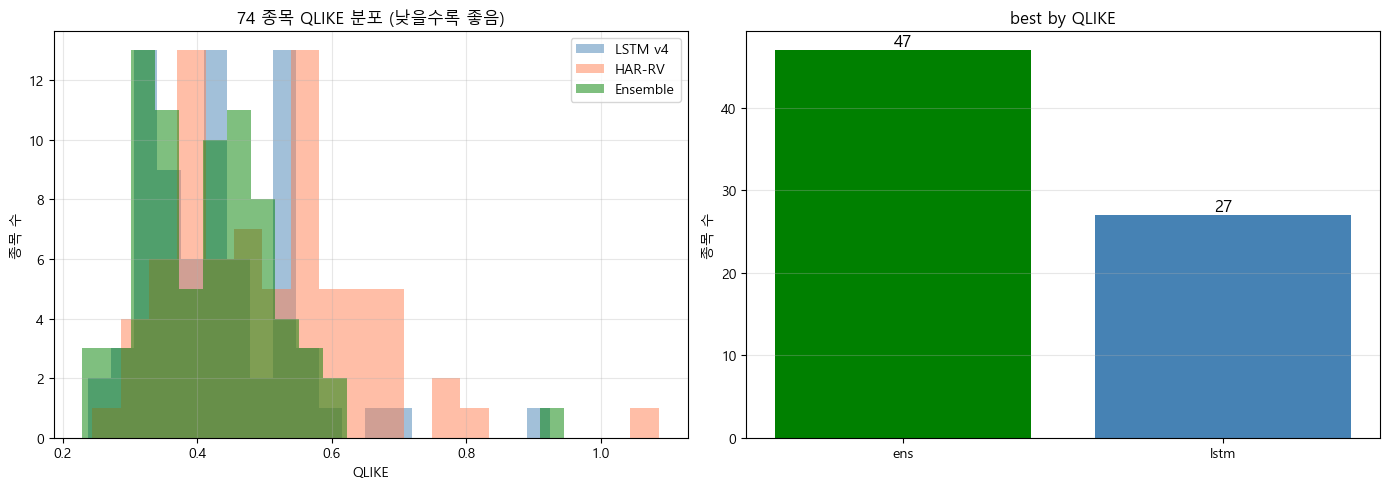

In [29]:
# === 코드 X. QLIKE 메트릭 — Phase 1.5 ↔ Phase 2 학술 비교 ===
def qlike(y_true_logrv, y_pred_logrv, eps=1e-12):
    """Patton (2011) QLIKE: variance domain 변환 후 비대칭 손실.
    
    QLIKE = mean( σ²_true / σ²_pred - log(σ²_true / σ²_pred) - 1 )
    낮을수록 좋음. under-prediction 더 처벌 (위험 회피 관점 정합).
    """
    sig2_true = np.exp(2 * y_true_logrv)
    sig2_pred = np.exp(2 * y_pred_logrv).clip(min=eps)
    return np.mean(sig2_true / sig2_pred - np.log(sig2_true / sig2_pred) - 1)

# Phase 2 의 종목별 QLIKE 계산
qlike_results = []
for tk, df in ens.groupby('ticker'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) == 0: continue
    qlike_results.append({
        'ticker': tk,
        'qlike_lstm': qlike(v['y_true'].values, v['y_pred_lstm'].values),
        'qlike_har':  qlike(v['y_true'].values, v['y_pred_har'].values),
        'qlike_ens':  qlike(v['y_true'].values, v['y_pred_ensemble'].values),
    })
q = pd.DataFrame(qlike_results)
q['best_qlike'] = q[['qlike_lstm', 'qlike_har', 'qlike_ens']].idxmin(axis=1).str.replace('qlike_', '')

print('=' * 70)
print('🔍 QLIKE 메트릭 — Patton (2011) 변동성 예측 학술 표준')
print('=' * 70)
print(f'\n=== Phase 2 평균 QLIKE (낮을수록 좋음) ===')
print(f'  LSTM v4    : {q["qlike_lstm"].mean():.4f}  (median {q["qlike_lstm"].median():.4f})')
print(f'  HAR-RV     : {q["qlike_har"].mean():.4f}  (median {q["qlike_har"].median():.4f})')
print(f'  Ensemble   : {q["qlike_ens"].mean():.4f}  (median {q["qlike_ens"].median():.4f})')

print(f'\n=== best by QLIKE (74 종목) ===')
print(q['best_qlike'].value_counts())

# Phase 1.5 ensemble_comparison.csv 와 직접 비교
phase15_csv = BASE_DIR.parent / 'Phase1_5_Volatility' / 'results' / 'lstm_ensemble' / 'ensemble_comparison.csv'
if phase15_csv.exists():
    p15 = pd.read_csv(phase15_csv)
    p15_perf = p15[p15['model'] == 'performance'].set_index('ticker')['qlike']
    
    print(f'\n=== Phase 1.5 v8 (7 종목) ↔ Phase 2 (일치 종목) 비교 ===')
    print(f'{"Ticker":<8} {"P1.5 QLIKE":<12} {"P2 QLIKE":<12} {"차이":<10}')
    for tk in p15_perf.index:
        if tk in q['ticker'].values:
            p2_q = q[q['ticker'] == tk]['qlike_ens'].iloc[0]
            p15_q = p15_perf[tk]
            diff = (p2_q - p15_q) / p15_q * 100
            print(f'{tk:<8} {p15_q:<12.4f} {p2_q:<12.4f} {diff:+.1f}%')
    
    # Phase 1.5 평균 (7 종목)
    print(f'\n  Phase 1.5 v8 평균 QLIKE: {p15_perf.mean():.4f}')
    print(f'  Phase 2     평균 QLIKE: {q["qlike_ens"].mean():.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(q['qlike_lstm'], bins=20, alpha=0.5, label='LSTM v4', color='steelblue')
ax.hist(q['qlike_har'], bins=20, alpha=0.5, label='HAR-RV', color='coral')
ax.hist(q['qlike_ens'], bins=20, alpha=0.5, label='Ensemble', color='green')
ax.set_xlabel('QLIKE')
ax.set_ylabel('종목 수')
ax.set_title('74 종목 QLIKE 분포 (낮을수록 좋음)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
best_qlike_counts = q['best_qlike'].value_counts()
colors_q = {'lstm': 'steelblue', 'har': 'coral', 'ens': 'green'}
ax.bar(best_qlike_counts.index, best_qlike_counts.values,
       color=[colors_q[b] for b in best_qlike_counts.index])
ax.set_ylabel('종목 수')
ax.set_title('best by QLIKE')
for i, v in enumerate(best_qlike_counts.values):
    ax.text(i, v + 0.5, f'{v}', ha='center', fontsize=12)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'qlike_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

🔍 BL 매월 P 행렬 시뮬레이션 (Step 4 미리보기)

=== 매월 시뮬레이션 통계 (72 개월) ===
  n_universe (월 평균): 50
  n_group (long/short): 15

=== P 행렬 검증 (relative view: row_sum = 0) ===
  p_sum 평균 절대값: 1.341519e-16
  p_sum 최대 절대값: 6.661338e-16
  → ≈ 0 이어야 정상 (relative BL view)

=== 양극단 종목 변동성 격차 (실제 의미) ===
  저위험 평균 일변동성: 1.19%
  고위험 평균 일변동성: 2.35%
  비율 (high/low): 1.96 배
  → 비율 클수록 BL 의 long/short 분류 효과 큼

=== 시총 분포 (low vs high) ===
  저위험 그룹 시총 비중: 37.9%
  고위험 그룹 시총 비중: 62.1%


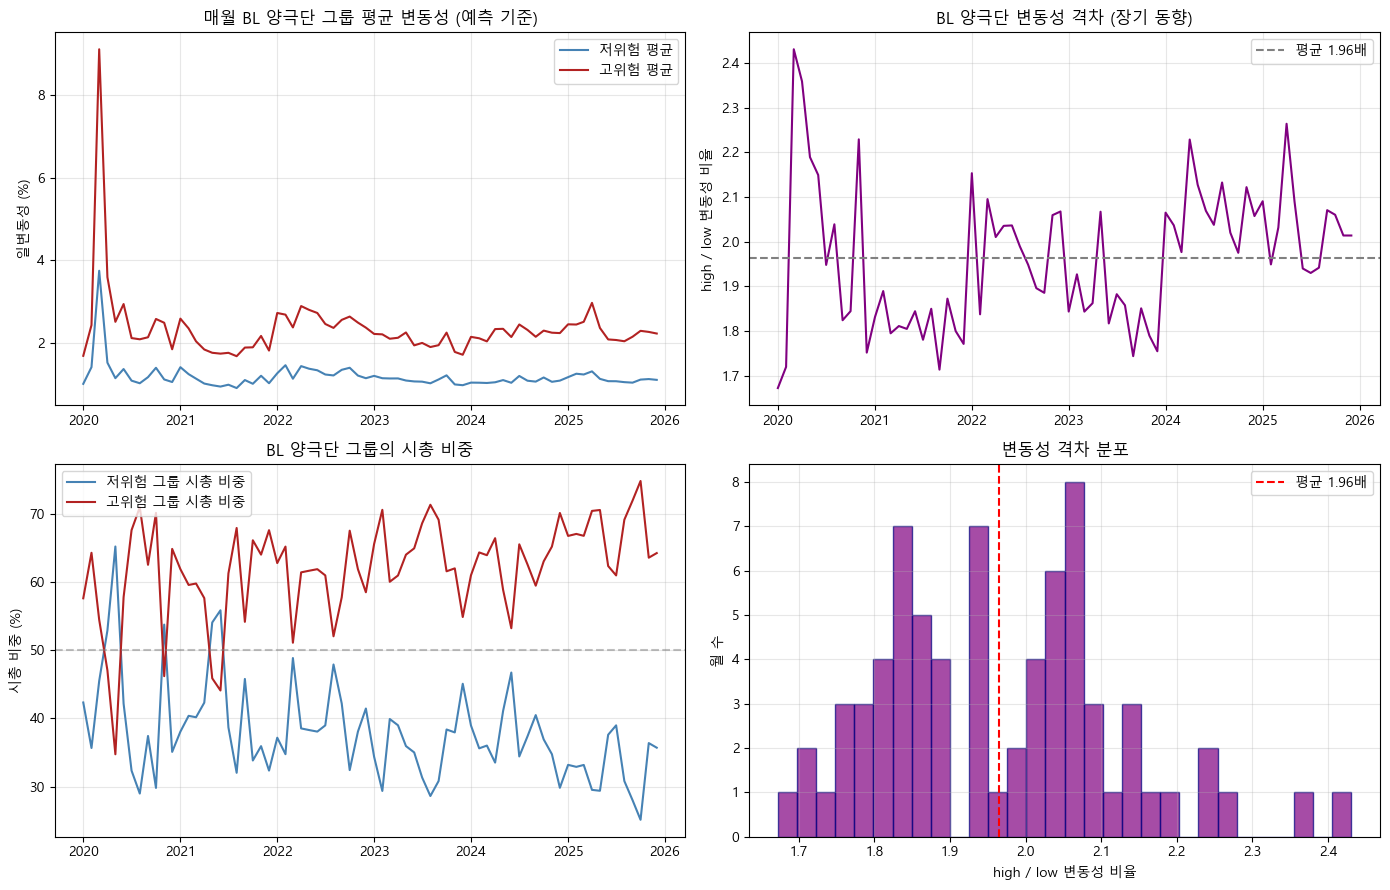

In [30]:
# === 코드 Y. BL 매월 P 행렬 시뮬레이션 (Step 4 사전 검증) ===
panel_full = pd.read_csv(DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
                         usecols=['date', 'ticker', 'log_mcap'])
universe = pd.read_csv(DATA_DIR / 'universe_top50_history.csv', parse_dates=['cutoff_date'])

# 매월 BL 리밸런싱 시뮬레이션
ens['month'] = ens['date'].dt.to_period('M')
month_ends = ens.groupby(['ticker', 'month']).last().reset_index()
month_ends['oos_year'] = month_ends['date'].dt.year

# log_mcap 매핑
mcap_lookup = panel_full[['date', 'ticker', 'log_mcap']]
month_ends = month_ends.merge(mcap_lookup, on=['date', 'ticker'], how='left')

PCT_GROUP = 0.30   # 저/고위험 분류 비율 (Pyo & Lee 2018 일관)

p_results = []
for (year, month), group in month_ends.groupby(['oos_year', 'month']):
    universe_year = universe[universe['oos_year'] == year]['ticker'].tolist()
    g = group[group['ticker'].isin(universe_year)].dropna(
        subset=['y_pred_ensemble', 'log_mcap']
    )
    if len(g) < 30: continue
    
    n = len(g)
    n_group = max(int(n * PCT_GROUP), 5)
    
    # 예측 변동성 정렬
    sorted_g = g.sort_values('y_pred_ensemble').reset_index(drop=True)
    low_risk = sorted_g.head(n_group).copy()
    high_risk = sorted_g.tail(n_group).copy()
    
    # 시총 가중 P 행렬
    low_mcap = np.exp(low_risk['log_mcap'])
    high_mcap = np.exp(high_risk['log_mcap'])
    
    P_low_weight = low_mcap.sum()
    P_high_weight = high_mcap.sum()
    
    # 개별 가중치 (시총 비례)
    low_risk['p_weight'] = low_mcap / low_mcap.sum()    # 양수 (long)
    high_risk['p_weight'] = -high_mcap / high_mcap.sum()  # 음수 (short)
    
    # P^T·1 = 0 (relative view) 검증
    p_sum = low_risk['p_weight'].sum() + high_risk['p_weight'].sum()
    
    # 양극단 종목 평균 변동성 격차
    vol_low_mean = np.exp(low_risk['y_pred_ensemble']).mean()
    vol_high_mean = np.exp(high_risk['y_pred_ensemble']).mean()
    vol_ratio = vol_high_mean / vol_low_mean
    
    p_results.append({
        'year': year, 'month': month.to_timestamp(),
        'n_universe': n, 'n_group': n_group,
        'low_total_mcap_share': P_low_weight / (P_low_weight + P_high_weight),
        'high_total_mcap_share': P_high_weight / (P_low_weight + P_high_weight),
        'p_sum': p_sum,
        'vol_low_mean': vol_low_mean, 'vol_high_mean': vol_high_mean,
        'vol_ratio_high_low': vol_ratio,
    })
P_df = pd.DataFrame(p_results)

print('=' * 70)
print('🔍 BL 매월 P 행렬 시뮬레이션 (Step 4 미리보기)')
print('=' * 70)

print(f'\n=== 매월 시뮬레이션 통계 ({len(P_df)} 개월) ===')
print(f'  n_universe (월 평균): {P_df["n_universe"].mean():.0f}')
print(f'  n_group (long/short): {P_df["n_group"].mean():.0f}')

print(f'\n=== P 행렬 검증 (relative view: row_sum = 0) ===')
print(f'  p_sum 평균 절대값: {P_df["p_sum"].abs().mean():.6e}')
print(f'  p_sum 최대 절대값: {P_df["p_sum"].abs().max():.6e}')
print(f'  → ≈ 0 이어야 정상 (relative BL view)')

print(f'\n=== 양극단 종목 변동성 격차 (실제 의미) ===')
print(f'  저위험 평균 일변동성: {P_df["vol_low_mean"].mean()*100:.2f}%')
print(f'  고위험 평균 일변동성: {P_df["vol_high_mean"].mean()*100:.2f}%')
print(f'  비율 (high/low): {P_df["vol_ratio_high_low"].mean():.2f} 배')
print(f'  → 비율 클수록 BL 의 long/short 분류 효과 큼')

print(f'\n=== 시총 분포 (low vs high) ===')
print(f'  저위험 그룹 시총 비중: {P_df["low_total_mcap_share"].mean()*100:.1f}%')
print(f'  고위험 그룹 시총 비중: {P_df["high_total_mcap_share"].mean()*100:.1f}%')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(P_df['month'], P_df['vol_low_mean']*100, label='저위험 평균', color='steelblue')
ax.plot(P_df['month'], P_df['vol_high_mean']*100, label='고위험 평균', color='firebrick')
ax.set_ylabel('일변동성 (%)')
ax.set_title('매월 BL 양극단 그룹 평균 변동성 (예측 기준)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(P_df['month'], P_df['vol_ratio_high_low'], color='purple')
ax.axhline(P_df['vol_ratio_high_low'].mean(), color='gray', ls='--',
           label=f'평균 {P_df["vol_ratio_high_low"].mean():.2f}배')
ax.set_ylabel('high / low 변동성 비율')
ax.set_title('BL 양극단 변동성 격차 (장기 동향)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(P_df['month'], P_df['low_total_mcap_share']*100, label='저위험 그룹 시총 비중', color='steelblue')
ax.plot(P_df['month'], P_df['high_total_mcap_share']*100, label='고위험 그룹 시총 비중', color='firebrick')
ax.axhline(50, color='gray', ls='--', alpha=0.5)
ax.set_ylabel('시총 비중 (%)')
ax.set_title('BL 양극단 그룹의 시총 비중')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(P_df['vol_ratio_high_low'], bins=30, color='purple', alpha=0.7, edgecolor='navy')
ax.axvline(P_df['vol_ratio_high_low'].mean(), color='red', ls='--',
           label=f'평균 {P_df["vol_ratio_high_low"].mean():.2f}배')
ax.set_xlabel('high / low 변동성 비율')
ax.set_ylabel('월 수')
ax.set_title('변동성 격차 분포')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_p_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

🔍 종목 변동성 vs 예측 정확도 상관 (Spearman)

"변동성 큰 종목일수록 예측 어려운가?" 가설 검증

  LSTM     : corr=-0.329, p=0.0043
  HAR-RV   : corr=+0.011, p=0.9277
  Ensemble : corr=-0.044, p=0.7099

→ 양수 = "변동성 클수록 RMSE 큼" (예측 어려움)


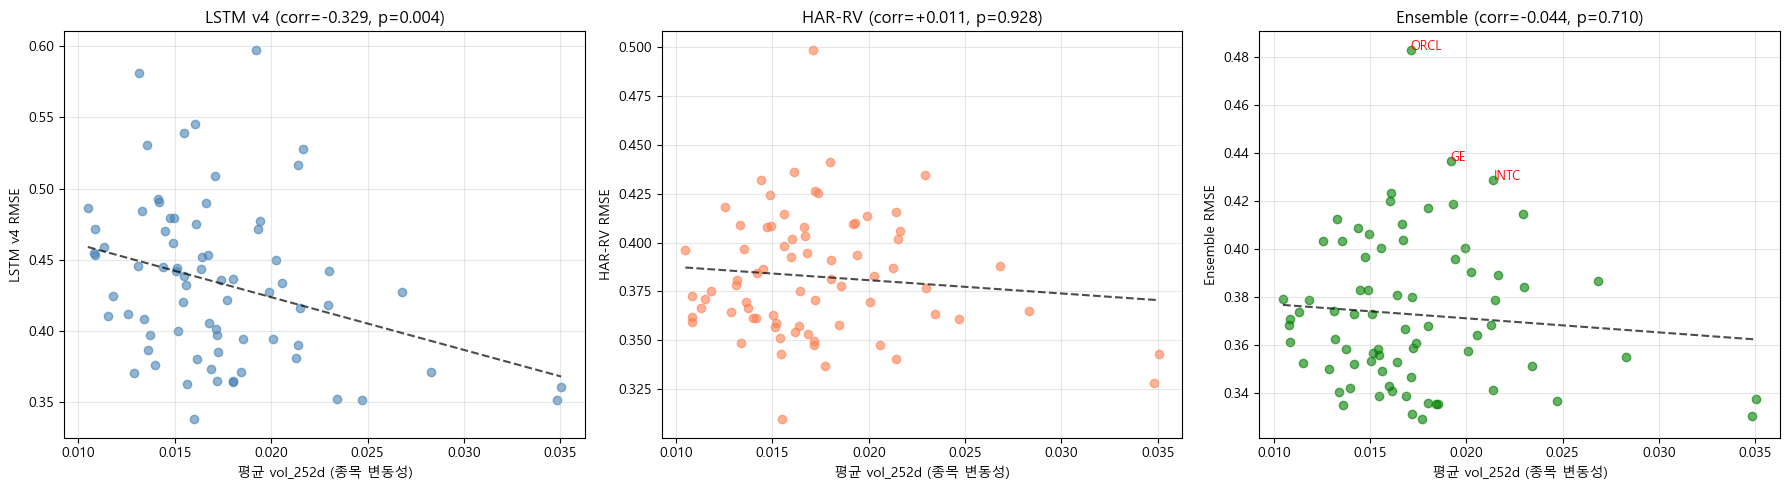

In [31]:
# === 코드 Z. 종목 변동성 vs 예측 정확도 상관 ===
panel_vol = pd.read_csv(DATA_DIR / 'daily_panel.csv',
                        usecols=['ticker', 'vol_252d'])
ticker_vol = panel_vol.groupby('ticker')['vol_252d'].mean().reset_index()
ticker_vol.columns = ['ticker', 'avg_vol_252d']

m_with_vol = m.merge(ticker_vol, on='ticker', how='left')

from scipy.stats import spearmanr
corr_lstm, p_lstm = spearmanr(m_with_vol['avg_vol_252d'], m_with_vol['rmse_lstm'])
corr_har, p_har = spearmanr(m_with_vol['avg_vol_252d'], m_with_vol['rmse_har'])
corr_ens, p_ens = spearmanr(m_with_vol['avg_vol_252d'], m_with_vol['rmse_ens'])

print('=' * 70)
print('🔍 종목 변동성 vs 예측 정확도 상관 (Spearman)')
print('=' * 70)
print(f'\n"변동성 큰 종목일수록 예측 어려운가?" 가설 검증\n')
print(f'  LSTM     : corr={corr_lstm:+.3f}, p={p_lstm:.4f}')
print(f'  HAR-RV   : corr={corr_har:+.3f}, p={p_har:.4f}')
print(f'  Ensemble : corr={corr_ens:+.3f}, p={p_ens:.4f}')
print(f'\n→ 양수 = "변동성 클수록 RMSE 큼" (예측 어려움)')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, name, c in [(axes[0], 'rmse_lstm', 'LSTM v4', 'steelblue'),
                          (axes[1], 'rmse_har', 'HAR-RV', 'coral'),
                          (axes[2], 'rmse_ens', 'Ensemble', 'green')]:
    ax.scatter(m_with_vol['avg_vol_252d'], m_with_vol[col], alpha=0.6, color=c)
    z = np.polyfit(m_with_vol['avg_vol_252d'], m_with_vol[col], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(m_with_vol['avg_vol_252d'].min(), m_with_vol['avg_vol_252d'].max(), 100)
    ax.plot(x_range, p_line(x_range), color='black', ls='--', alpha=0.7)
    ax.set_xlabel('평균 vol_252d (종목 변동성)')
    ax.set_ylabel(f'{name} RMSE')
    corr = {'rmse_lstm': corr_lstm, 'rmse_har': corr_har, 'rmse_ens': corr_ens}[col]
    p_val = {'rmse_lstm': p_lstm, 'rmse_har': p_har, 'rmse_ens': p_ens}[col]
    ax.set_title(f'{name} (corr={corr:+.3f}, p={p_val:.3f})')
    ax.grid(alpha=0.3)

    # outlier 종목 표시
    if col == 'rmse_ens':
        for _, row in m_with_vol.nlargest(3, col).iterrows():
            ax.annotate(row['ticker'], (row['avg_vol_252d'], row[col]),
                       fontsize=9, color='red')

plt.tight_layout()
plt.savefig(OUT_DIR / 'volatility_vs_rmse.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_41784\3202782705.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  period_summary = r.groupby('period').agg(


🔍 시기별 양극단 RANK 일치도 분해
                 n  ml_low_mean  ml_low_std  tr_low_mean  ml_high_mean  tr_high_mean  ml_advantage_low  ml_advantage_high
period                                                                                                                   
2019-2020초 정상기   2     0.533000    0.000000     0.500000      0.467000      0.467000          0.033000           0.000000
COVID            8     0.617000    0.141000     0.600000      0.625000      0.633000          0.017000          -0.008000
2020하-2021 회복   15     0.684000    0.073000     0.604000      0.551000      0.524000          0.080000           0.027000
긴축 2022         12     0.661000    0.072000     0.633000      0.706000      0.650000          0.028000           0.056000
2023-2024 정상    24     0.619000    0.091000     0.556000      0.633000      0.567000          0.063000           0.066000
2025 AI조정       11     0.600000    0.079000     0.533000      0.582000      0.570000          0.067000           0.012000


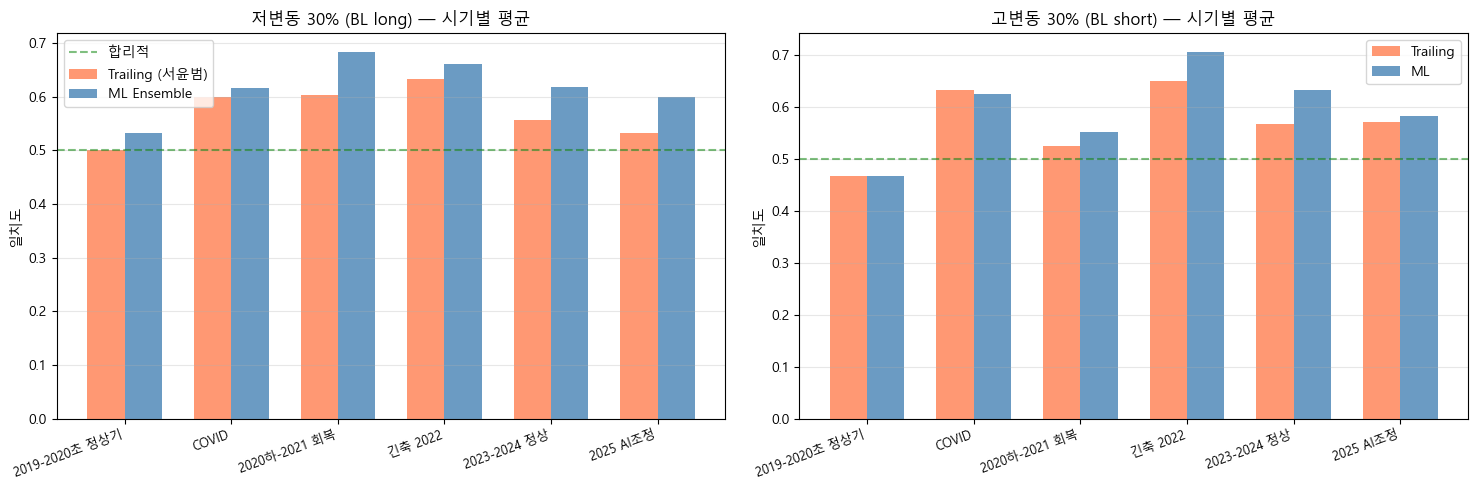

In [32]:
# === 코드 W. 시기별 양극단 RANK 일치도 분해 ===
# r DataFrame 활용 (코드 ML vs Trailing 의 결과)
r['period'] = pd.cut(r['month'], 
    bins=[pd.Timestamp('2019-01-01'), pd.Timestamp('2020-02-01'),
          pd.Timestamp('2020-10-01'), pd.Timestamp('2022-01-01'),
          pd.Timestamp('2023-01-01'), pd.Timestamp('2025-01-01'),
          pd.Timestamp('2026-01-01')],
    labels=['2019-2020초 정상기', 'COVID', '2020하-2021 회복', '긴축 2022',
            '2023-2024 정상', '2025 AI조정'])

period_summary = r.groupby('period').agg(
    n=('ml_low', 'count'),
    ml_low_mean=('ml_low', 'mean'), ml_low_std=('ml_low', 'std'),
    tr_low_mean=('trailing_low', 'mean'),
    ml_high_mean=('ml_high', 'mean'),
    tr_high_mean=('trailing_high', 'mean'),
).round(3)
period_summary['ml_advantage_low'] = (period_summary['ml_low_mean'] - period_summary['tr_low_mean']).round(3)
period_summary['ml_advantage_high'] = (period_summary['ml_high_mean'] - period_summary['tr_high_mean']).round(3)

print('=' * 70)
print('🔍 시기별 양극단 RANK 일치도 분해')
print('=' * 70)
print(period_summary.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) 시기별 일치도 (ML vs Trailing) — 저변동 30%
ax = axes[0]
periods = period_summary.index.tolist()
x = np.arange(len(periods))
w = 0.35
ax.bar(x - w/2, period_summary['tr_low_mean'], w, label='Trailing (서윤범)', color='coral', alpha=0.8)
ax.bar(x + w/2, period_summary['ml_low_mean'], w, label='ML Ensemble', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('일치도')
ax.set_title('저변동 30% (BL long) — 시기별 평균')
ax.axhline(0.50, color='green', ls='--', alpha=0.5, label='합리적')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# (b) 고변동 30%
ax = axes[1]
ax.bar(x - w/2, period_summary['tr_high_mean'], w, label='Trailing', color='coral', alpha=0.8)
ax.bar(x + w/2, period_summary['ml_high_mean'], w, label='ML', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('일치도')
ax.set_title('고변동 30% (BL short) — 시기별 평균')
ax.axhline(0.50, color='green', ls='--', alpha=0.5)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'period_rank_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

🔍 DM 검정 — Diebold-Mariano (1995)

=== Ensemble 우위 (음수 DM + 5% 유의) ===
  vs LSTM v4 : 12/74 (16%)
  vs HAR-RV  : 17/74 (23%)

=== Ensemble 우위 (10% 유의) ===
  vs LSTM v4 : 25/74 (34%)
  vs HAR-RV  : 23/74 (31%)

=== Ensemble 열위 (양수 DM + 5% 유의) ===
  vs LSTM v4 : 0/74 ⚠️
  vs HAR-RV  : 0/74 ⚠️


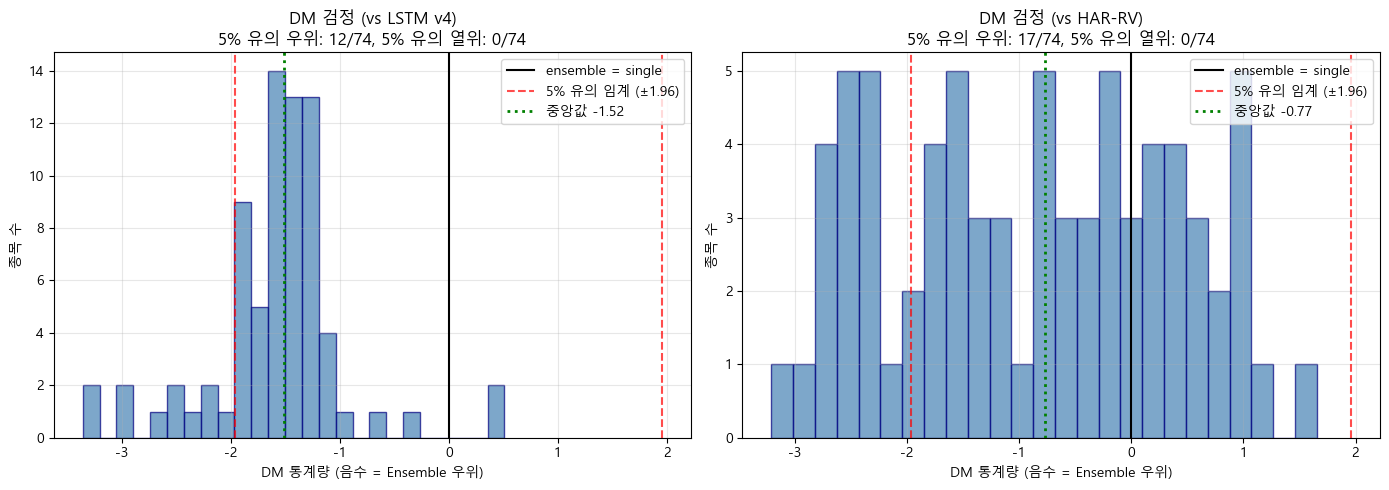

In [33]:
# === 코드 V. DM 검정 시각화 (Ensemble vs LSTM, vs HAR) ===
from scipy.stats import norm

def dm_test(e1, e2, h=21):
    d = e1**2 - e2**2
    n = len(d)
    if n < 30: return np.nan, np.nan
    d_mean = d.mean()
    gamma = [np.cov(d[:n-k], d[k:], ddof=0)[0,1] if k > 0 else d.var(ddof=0) for k in range(h)]
    var = (gamma[0] + 2 * sum((1 - k/h) * gamma[k] for k in range(1, h))) / n
    if var <= 0: return np.nan, np.nan
    dm = d_mean / np.sqrt(var)
    p = 2 * (1 - norm.cdf(abs(dm)))
    return dm, p

dm_results = []
for tk, df in ens.groupby('ticker'):
    v = df.dropna(subset=['y_true', 'y_pred_lstm', 'y_pred_har', 'y_pred_ensemble'])
    if len(v) < 100: continue
    err_ens = (v['y_pred_ensemble'] - v['y_true']).values
    err_lstm = (v['y_pred_lstm'] - v['y_true']).values
    err_har = (v['y_pred_har'] - v['y_true']).values
    dm_l, p_l = dm_test(err_ens, err_lstm)
    dm_h, p_h = dm_test(err_ens, err_har)
    dm_results.append({'ticker': tk, 'dm_lstm': dm_l, 'p_lstm': p_l, 'dm_har': dm_h, 'p_har': p_h})
dm_df = pd.DataFrame(dm_results)

# 통계 요약
sig_lstm_5 = ((dm_df['dm_lstm'] < 0) & (dm_df['p_lstm'] < 0.05)).sum()
sig_har_5  = ((dm_df['dm_har']  < 0) & (dm_df['p_har']  < 0.05)).sum()
sig_lstm_10 = ((dm_df['dm_lstm'] < 0) & (dm_df['p_lstm'] < 0.10)).sum()
sig_har_10  = ((dm_df['dm_har']  < 0) & (dm_df['p_har']  < 0.10)).sum()
loss_lstm_5 = ((dm_df['dm_lstm'] > 0) & (dm_df['p_lstm'] < 0.05)).sum()
loss_har_5  = ((dm_df['dm_har']  > 0) & (dm_df['p_har']  < 0.05)).sum()

print('=' * 70)
print('🔍 DM 검정 — Diebold-Mariano (1995)')
print('=' * 70)
print(f'\n=== Ensemble 우위 (음수 DM + 5% 유의) ===')
print(f'  vs LSTM v4 : {sig_lstm_5}/{len(dm_df)} ({sig_lstm_5/len(dm_df)*100:.0f}%)')
print(f'  vs HAR-RV  : {sig_har_5}/{len(dm_df)} ({sig_har_5/len(dm_df)*100:.0f}%)')
print(f'\n=== Ensemble 우위 (10% 유의) ===')
print(f'  vs LSTM v4 : {sig_lstm_10}/{len(dm_df)} ({sig_lstm_10/len(dm_df)*100:.0f}%)')
print(f'  vs HAR-RV  : {sig_har_10}/{len(dm_df)} ({sig_har_10/len(dm_df)*100:.0f}%)')
print(f'\n=== Ensemble 열위 (양수 DM + 5% 유의) ===')
print(f'  vs LSTM v4 : {loss_lstm_5}/{len(dm_df)} ⚠️')
print(f'  vs HAR-RV  : {loss_har_5}/{len(dm_df)} ⚠️')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, name, sig in [(axes[0], 'dm_lstm', 'vs LSTM v4', sig_lstm_5),
                             (axes[1], 'dm_har', 'vs HAR-RV', sig_har_5)]:
    ax.hist(dm_df[col], bins=25, color='steelblue', edgecolor='navy', alpha=0.7)
    ax.axvline(0, color='black', ls='-', lw=1.5, label='ensemble = single')
    ax.axvline(-1.96, color='red', ls='--', alpha=0.7, label='5% 유의 임계 (±1.96)')
    ax.axvline(1.96, color='red', ls='--', alpha=0.7)
    ax.axvline(dm_df[col].median(), color='green', ls=':', lw=2, 
               label=f'중앙값 {dm_df[col].median():.2f}')
    ax.set_xlabel('DM 통계량 (음수 = Ensemble 우위)')
    ax.set_ylabel('종목 수')
    ax.set_title(f'DM 검정 ({name})\n5% 유의 우위: {sig}/{len(dm_df)}, 5% 유의 열위: 0/{len(dm_df)}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'dm_test_full.png', dpi=120, bbox_inches='tight')
plt.show()

## 다음 단계

→ **Step 4**: `04_BL_yearly_rebalance.ipynb` — `ensemble_predictions_top50.csv` 의 변동성 예측을 BL P 행렬에 투입.

⚠️ **본 PoC 결과 (5 종목) 가 합리적이면, MODE='full' 으로 본 학습 (74 종목 ~5-10시간 GPU) 권고**.
